# 輕度認知障礙與失智症EEG特徵提取

In [37]:
from collections import Counter
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import f_oneway, ttest_ind, spearmanr, pearsonr
import mne, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 設置紀錄為 'WARNING' 或更高，以隱藏不必要的輸出
mne.set_log_level('WARNING')

檔案路徑

In [38]:
path_hc = 'C:/Users/kitt9/OneDrive - National ChengChi University/eeg-rag-llm-diag/dataset_sorted/sample_test/sample/HC/'
path_mci = 'C:/Users/kitt9/OneDrive - National ChengChi University/eeg-rag-llm-diag/dataset_sorted/sample_test/sample/MCI/'
path_ad = 'C:/Users/kitt9/OneDrive - National ChengChi University/eeg-rag-llm-diag/dataset_sorted/sample_test/sample/AD/'

## 絕對功率

In [39]:
def EEG_calculate_PSD(path, event_name='Eyes Open', delay_time=0, cut_time=8):
    filesname = os.listdir(path)
    total_mean_psd_results = []
    filenames = []

    for filename in filesname:
        file_path = os.path.join(path, filename)

        try:
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        except Exception as e:
            print(f"Error processing file {filename}: {e}")
            continue

        # 提取事件
        events, event_id = mne.events_from_annotations(raw, verbose=False)

        # 選擇事件 (ex. 'Eyes Open')
        try:
            s_events = events[events[:, 2] == event_id[event_name]]
        except Exception as e:
            print(f"No Event Error File {filename}: {e}")
            continue

        # 移除Photic通道
        if 'Photic' in raw.info['ch_names']:
            raw.drop_channels(['Photic'])

        # 定義處理參數
        fs = int(raw.info['sfreq'])  # 取樣率，確保為整數
        filter_low, filter_high = 0.5, 50  # Bandpass Filter範圍

        # 提取ch_names，與建立ch_types
        ch_names = raw.info['ch_names']
        ch_types = ['eeg'] * len(ch_names)  

        # 初始化存儲每個通道的PSD結果的列表
        psd_results = {ch_name: [] for ch_name in ch_names}

        # 遍歷每個 'Eyes Open' 事件
        for s_event in s_events:
            event_start = s_event[0]
            delay = delay_time  # delay_time 預設為 0
            time = cut_time # cut_time 預設為 8
            start_sample = event_start + int(fs * delay)  # 事件後延遲 delay 秒的開始樣本，若沒有要延遲為0
            end_sample = start_sample + int(fs * time)  # time 秒長度的樣本

            if end_sample > len(raw): continue  # 避免超出數據範圍

            # 提取事件後的 time 秒數據
            event_data, _ = raw[:, start_sample:end_sample]
                
            # 濾波
            event_data_filtered = mne.filter.filter_data(event_data, sfreq=fs, l_freq=filter_low, h_freq=filter_high, verbose=False)
            
            # 創建 mne.io.RawArray
            info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)
            epoch_raw = mne.io.RawArray(event_data_filtered, info, verbose=False)
            epoch_data_clean = epoch_raw.get_data()

            # 計算每個通道的PSD
            for ch_idx, ch_name in enumerate(ch_names):
                psd, freqs = mne.time_frequency.psd_array_welch(epoch_data_clean[ch_idx], 
                                                                sfreq=fs, fmin=filter_low, fmax=filter_high, 
                                                                n_fft=int(fs*2), verbose=False)
                psd = psd * (1e6 ** 2) # PSD單位原先為 µV²/Hz 轉換為 V²/Hz
                psd_results[ch_name].append(psd)

        # 計算每個通道所有 epoch 的 PSD 均值和標準差
        mean_psd_results = {ch_name: np.mean(psds, axis=0) for ch_name, psds in psd_results.items()}
        total_mean_psd_results.append(mean_psd_results)
        filenames.append(filename)  # 儲存檔名

    return total_mean_psd_results, filenames, freqs

In [40]:
HC_psd, HC_filenames, freqs = EEG_calculate_PSD(path=path_hc, event_name='Eyes Closed', delay_time=0, cut_time=8)
MCI_psd, MCI_filenames, freqs = EEG_calculate_PSD(path=path_mci, event_name='Eyes Closed', delay_time=0, cut_time=8)
AD_psd, AD_filenames, freqs = EEG_calculate_PSD(path=path_ad, event_name='Eyes Closed', delay_time=0, cut_time=8)

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.interpolate import make_interp_spline

# -------------------------
# 1) 先定義：把每個檔（同一群組）內「每通道的 epoch 平均 PSD（線性）」轉 dB，再做群組平均/標準差（dB 空間）
# -------------------------
def calculate_mean_std_psd(psd_dict):
    # 僅保留通道數完整的結果（避免 None 或少通道）
    valid_mean_psd_results = [result for result in psd_dict if len(result) == 18]
    ch_names = list(valid_mean_psd_results[0].keys())
    overall_mean_psd = {ch_name: [] for ch_name in ch_names}

    for file_mean_psd in valid_mean_psd_results:
        for ch_name in ch_names:
            # 你的 file_mean_psd[ch_name] 已是「該檔案/通道的 epoch 平均 PSD（線性）」
            # 這裡轉 dB 後再做群組平均（dB 平均）
            overall_mean_psd[ch_name].append(10 * np.log10(file_mean_psd[ch_name]))

    final_mean_psd = {ch_name: np.mean(overall_mean_psd[ch_name], axis=0) for ch_name in ch_names}
    final_std_psd  = {ch_name: np.std (overall_mean_psd[ch_name], axis=0) for ch_name in ch_names}
    return final_mean_psd, final_std_psd

# -------------------------
# 2) 計算三組的群組平均 PSD（dB）與標準差（dB）
# -------------------------
HC_mean_psd, HC_std_psd = calculate_mean_std_psd(HC_psd)
MCI_mean_psd, MCI_std_psd = calculate_mean_std_psd(MCI_psd)
AD_mean_psd,  AD_std_psd  = calculate_mean_std_psd(AD_psd)

# 取所有通道名
ch_names = list(HC_mean_psd.keys())

# -------------------------
# 3) 頻帶選擇（例：0.5–12 Hz）
# -------------------------
desired_freq_band = (0.5, 12)
desired_freq_band_idx = np.where((freqs >= desired_freq_band[0]) & (freqs <= desired_freq_band[1]))[0]

# -------------------------
# 4) 先「一次」算好每個頻率的 t-test（用 dB 值）
# -------------------------
def calculate_ttest_p_values(HC_psd, MCI_psd, AD_psd, ch_names, freq_indices):
    p_values = {ch_name: {'HC_MCI': [], 'HC_AD': [], 'MCI_AD': []} for ch_name in ch_names}
    t_values = {ch_name: {'HC_MCI': [], 'HC_AD': [], 'MCI_AD': []} for ch_name in ch_names}

    for ch_name in ch_names:
        for freq_idx in freq_indices:
            # 從各檔案取出該通道該頻率的 PSD（線性），轉 dB 做統計
            hc_values  = [10 * np.log10(file_psd[ch_name][freq_idx]) for file_psd in HC_psd]
            mci_values = [10 * np.log10(file_psd[ch_name][freq_idx]) for file_psd in MCI_psd]
            ad_values  = [10 * np.log10(file_psd[ch_name][freq_idx]) for file_psd in AD_psd]

            # Welch's t-test（變異數不等）
            t_stat_hc_mci, p_value_hc_mci = ttest_ind(hc_values,  mci_values, equal_var=False)
            t_stat_hc_ad,  p_value_hc_ad  = ttest_ind(hc_values,  ad_values,  equal_var=False)
            t_stat_mci_ad, p_value_mci_ad = ttest_ind(mci_values, ad_values,  equal_var=False)

            p_values[ch_name]['HC_MCI'].append(p_value_hc_mci)
            p_values[ch_name]['HC_AD'].append(p_value_hc_ad)
            p_values[ch_name]['MCI_AD'].append(p_value_mci_ad)

            t_values[ch_name]['HC_MCI'].append(t_stat_hc_mci)
            t_values[ch_name]['HC_AD'].append(t_stat_hc_ad)
            t_values[ch_name]['MCI_AD'].append(t_stat_mci_ad)

    return p_values, t_values

p_values, _ = calculate_ttest_p_values(HC_psd, MCI_psd, AD_psd, ch_names, desired_freq_band_idx)

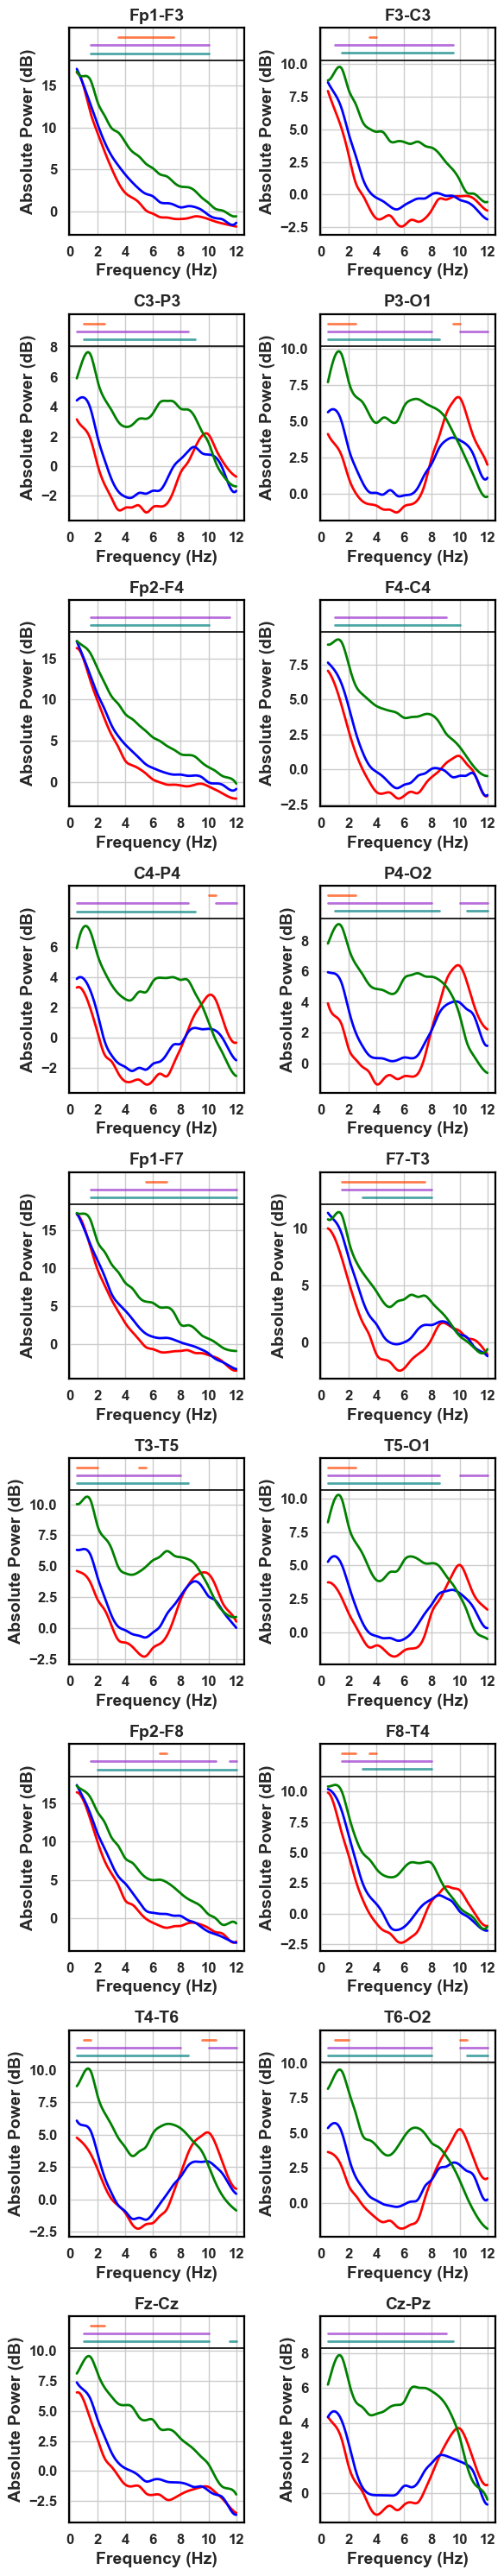

In [42]:

# -------------------------
# 5) 畫圖（含「方案 A：動態撐高 y 軸」）
# -------------------------
output_folder = 'PSD_individual_plots'
os.makedirs(output_folder, exist_ok=True)

fig, axes = plt.subplots(9, 2, figsize=(6, 30))
plot_idx = 0

# 顯著性設定（只要 0.05）
sig_levels   = {'<0.05': 0.05}
comparisons  = ['HC_MCI', 'HC_AD', 'MCI_AD']
colors       = {'HC_MCI': 'orangered', 'HC_AD': 'darkorchid', 'MCI_AD': 'teal'}

for ch_name in ch_names:
    ax = axes[plot_idx // 2, plot_idx % 2]

    # 取三組的群組平均 PSD（dB），限制到目標頻帶
    mean_psd_HC  = HC_mean_psd[ch_name][desired_freq_band_idx]
    mean_psd_MCI = MCI_mean_psd[ch_name][desired_freq_band_idx]
    mean_psd_AD  = AD_mean_psd[ch_name][desired_freq_band_idx]

    # 頻率座標（原始與平滑）
    freq_orig   = freqs[desired_freq_band_idx]
    freq_smooth = np.linspace(freq_orig.min(), freq_orig.max(), 200)

    # 曲線平滑（k=3，若擔心 overshoot 可改 k=2）
    psd_smooth_HC  = make_interp_spline(freq_orig, mean_psd_HC,  k=3)(freq_smooth)
    psd_smooth_MCI = make_interp_spline(freq_orig, mean_psd_MCI, k=3)(freq_smooth)
    psd_smooth_AD  = make_interp_spline(freq_orig, mean_psd_AD,  k=3)(freq_smooth)

    # 先畫三條曲線
    ax.plot(freq_smooth, psd_smooth_HC,  label='HC',       color='red',   lw=2.0)
    ax.plot(freq_smooth, psd_smooth_MCI, label='MCI',      color='blue',  lw=2.0)
    ax.plot(freq_smooth, psd_smooth_AD,  label='Dementia', color='green', lw=2.0)

    # ---------- 方案 A：動態撐高上界 ----------
    # 先以三條曲線的 min/max 估計振幅範圍
    y_top_curves = float(np.max([mean_psd_HC.max(), mean_psd_MCI.max(), mean_psd_AD.max()]))
    y_min_curves = float(np.min([mean_psd_HC.min(), mean_psd_MCI.min(), mean_psd_AD.min()]))
    span         = max(1e-6, y_top_curves - y_min_curves)

    # 動態 headroom（讓顯著線不會壓到曲線）
    headroom         = max(0.2, 0.1 * span)
    base_offset      = y_top_curves + headroom
    offset_increment = headroom * 0.5

    # 最高那條顯著線的位置（3 條：上、中、下）
    y_sig_top = base_offset + 2 * offset_increment
    ax.set_ylim(top=y_sig_top + headroom * 0.6)  # 先把上界撐到夠高

    # 黑色基準線（顯著線下緣）
    line_y = base_offset - offset_increment * 0.9
    ax.axhline(y=line_y, color='black', linestyle='-', lw=1.2)

    # ---------- 畫顯著區段（仍用資料座標） ----------
    already_plotted = set()
    freqs_band = freqs[desired_freq_band_idx]

    for comparison in comparisons:
        # 找顯著連續區段
        sig_regions = []
        for i, f in enumerate(freqs_band):
            if p_values[ch_name][comparison][i] < sig_levels['<0.05']:
                if not sig_regions or np.abs(f - sig_regions[-1][-1] - 0.5) > 1e-9:
                    sig_regions.append([f])
                else:
                    sig_regions[-1].append(f)

        # 各比較的顯著線層級（上/中/下）
        if comparison == 'HC_MCI':
            y_height = base_offset + 2 * offset_increment
        elif comparison == 'HC_AD':
            y_height = base_offset + 1 * offset_increment
        else:  # 'MCI_AD'
            y_height = base_offset + 0 * offset_increment

        # 畫線
        for region in sig_regions:
            line_label = f"{comparison.replace('_', ' vs ')} <0.05*"
            if line_label not in already_plotted:
                ax.plot(region, [y_height] * len(region), lw=2.0, color=colors[comparison],
                        alpha=0.7, label=line_label)
                already_plotted.add(line_label)
            else:
                ax.plot(region, [y_height] * len(region), lw=2.0, color=colors[comparison],
                        alpha=0.7)

    # ---------- ytick 只保留黑線以下 ----------
    y_min, y_max = ax.get_ylim()  # 此時 top 已撐高
    original_ticks = ax.get_yticks()
    filtered_ticks = [tick for tick in original_ticks if tick < line_y]
    ax.set_yticks(filtered_ticks)
    ax.set_ylim(y_min, y_max)     # 保持剛剛的 ylim

    # 美化
    ax.set_title(f'{ch_name[4:]}', fontsize=14, fontweight="bold")
    ax.set_xlabel('Frequency (Hz)', fontsize=14, fontweight="bold")
    ax.set_ylabel('Absolute Power (dB)', fontsize=14, fontweight="bold")
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
    ax.tick_params(axis='both', labelsize=12)
    # 若要圖例：打開下面這行
    # ax.legend(loc='upper left', fontsize=10)


    # --- 刻度字 粗體 ---
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    # --- 刻度線(短橫) 線寬加粗 ---
    ax.tick_params(axis='both', which='major', width=1.4, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)

    # --- 四周脊線(spines)加粗／顏色（外框感覺主要靠這個）---
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_linewidth(1.6)
        ax.spines[side].set_color("black")

    plot_idx += 1

plt.tight_layout()
plt.show()

## Alpha頻帶平均功率

In [43]:
def calculate_band_power(psd, freqs, band):
    band_freqs = [i for i, f in enumerate(freqs) if band[0] <= f < band[1]]
    band_power = {ch: np.mean([psd[ch][i] for i in band_freqs]) for ch in psd}
    return band_power

def calculate_mean_sd(psd_list, freqs, bands):
    all_band_powers = {band: {ch: [] for ch in psd_list[0].keys()} for band in bands}
    
    for psd in psd_list:
        psd_db = {ch: 10 * np.log10(np.array(psd[ch])) for ch in psd}
        for band_name, band_range in bands.items():
            band_power = calculate_band_power(psd_db, freqs, band_range)
            for ch in band_power:
                all_band_powers[band_name][ch].append(band_power[ch])
    
    mean_sd = {band: {ch: (np.mean(all_band_powers[band][ch]), np.std(all_band_powers[band][ch])) for ch in all_band_powers[band]} for band in bands}
    
    return all_band_powers, mean_sd

bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12)
}

# Calculate mean and standard deviation for each group
HC_band_powers, HC_mean_sd = calculate_mean_sd(HC_psd, freqs, bands)
MCI_band_powers, MCI_mean_sd = calculate_mean_sd(MCI_psd, freqs, bands)
AD_band_powers, AD_mean_sd = calculate_mean_sd(AD_psd, freqs, bands)

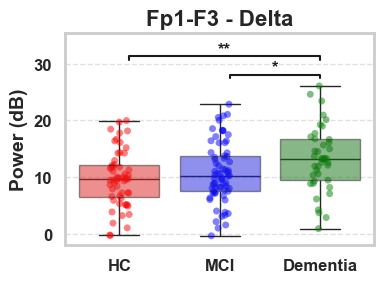

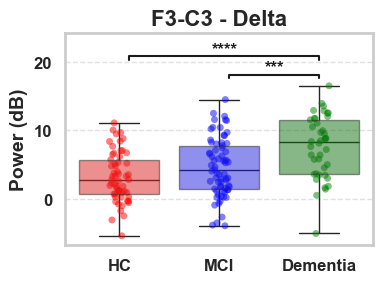

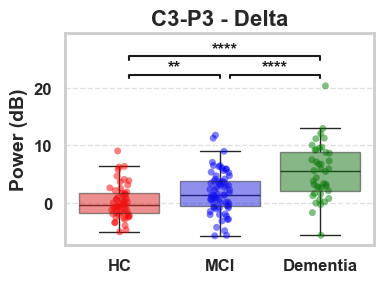

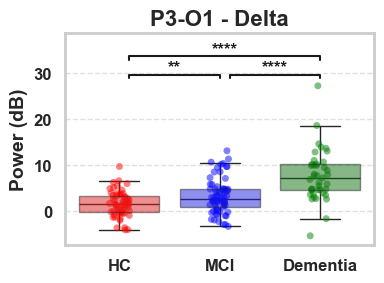

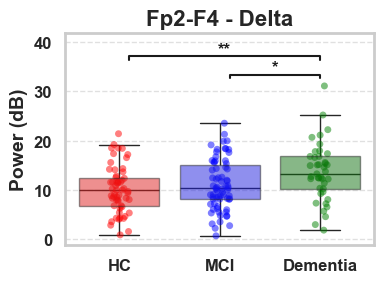

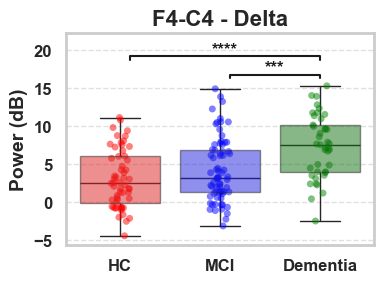

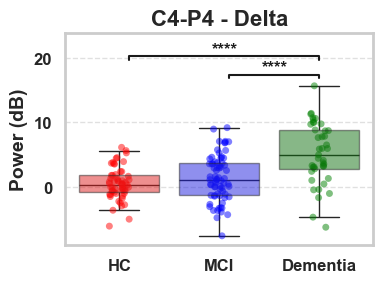

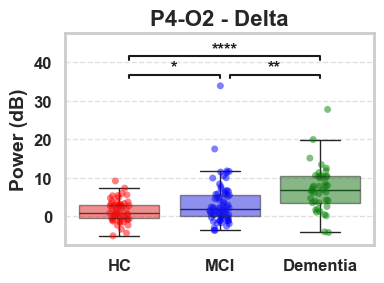

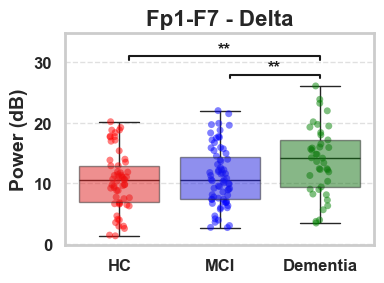

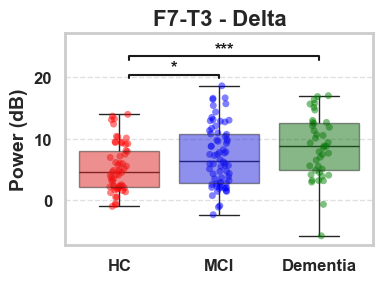

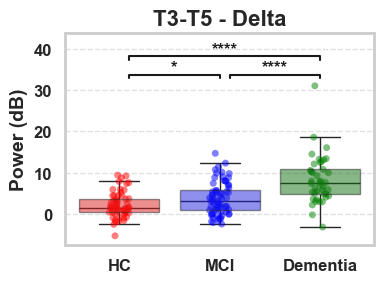

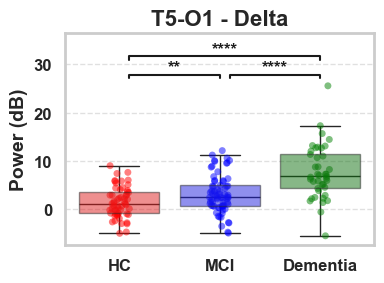

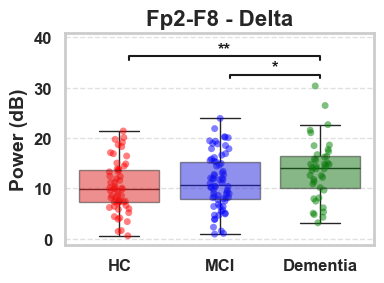

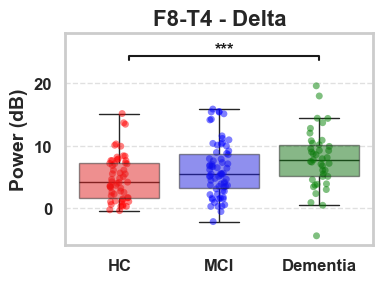

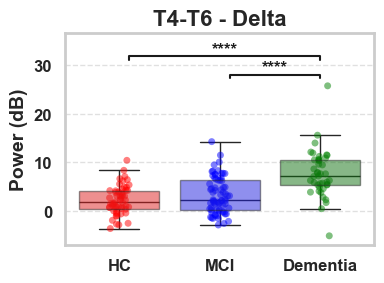

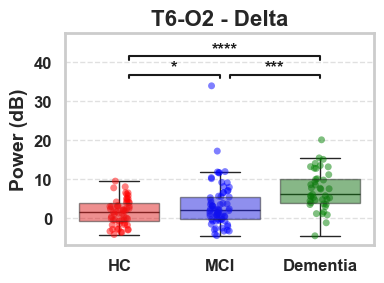

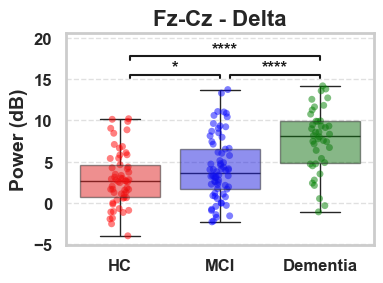

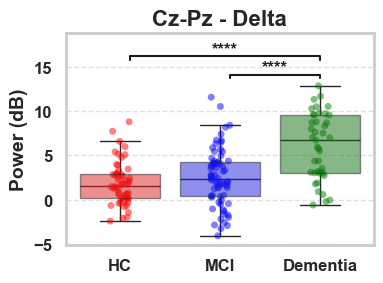

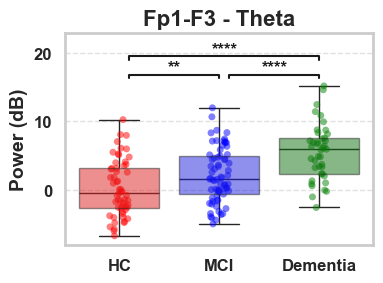

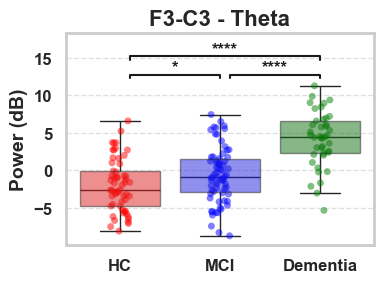

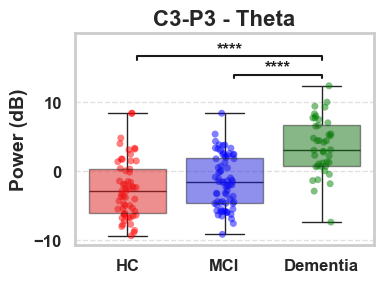

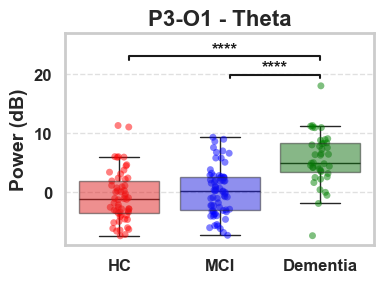

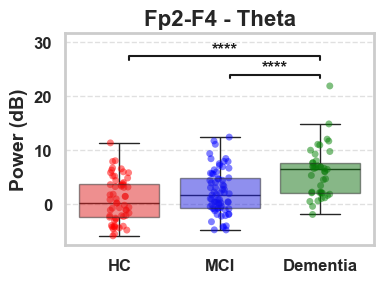

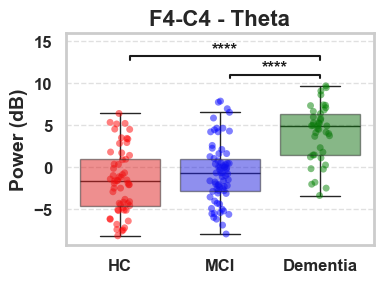

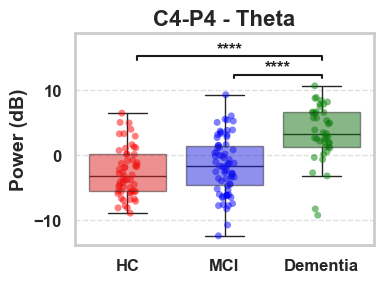

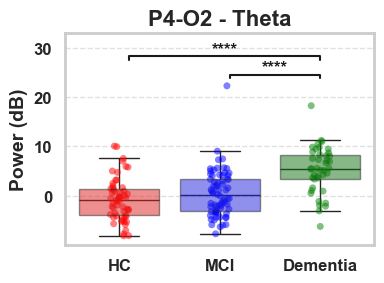

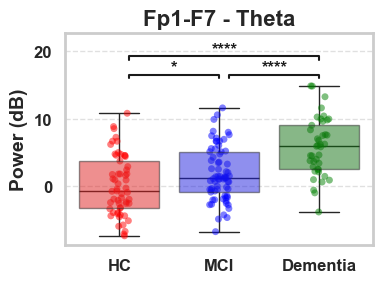

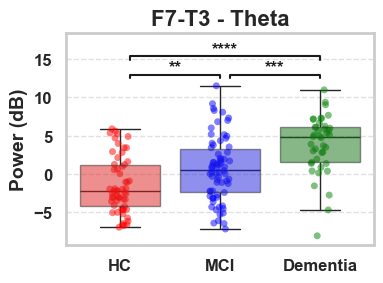

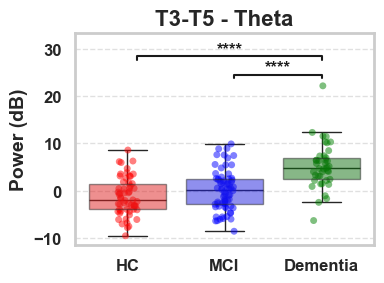

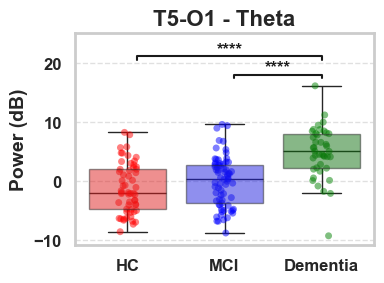

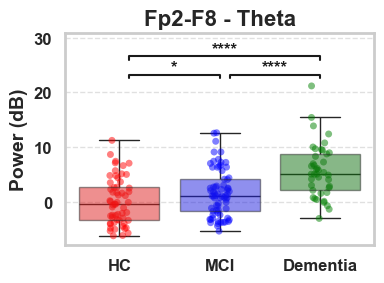

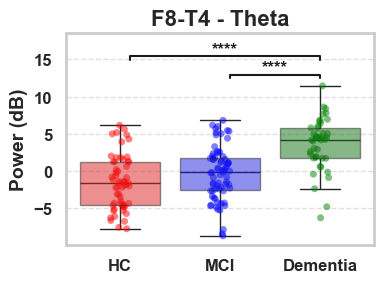

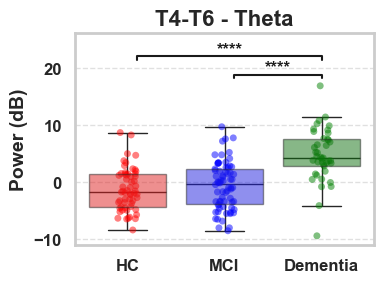

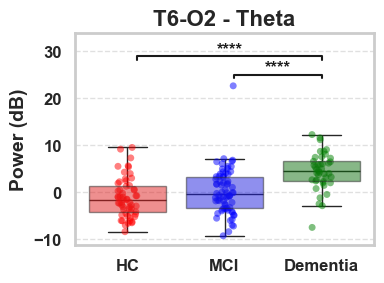

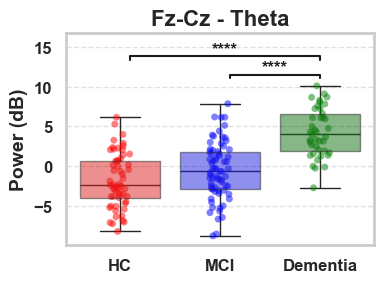

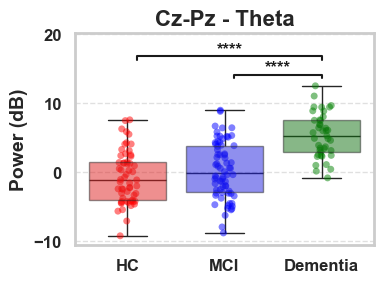

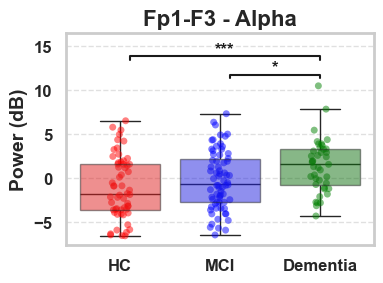

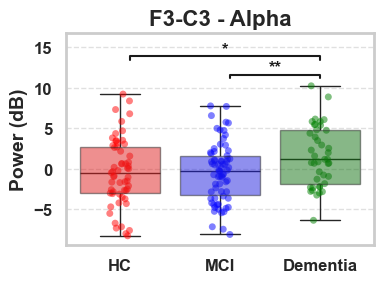

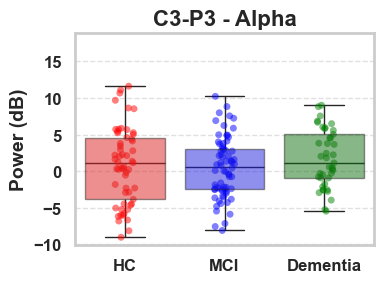

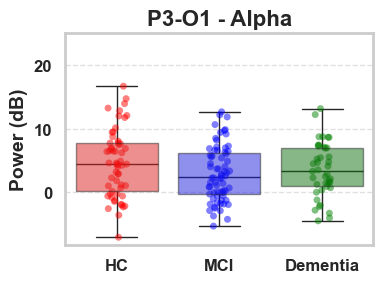

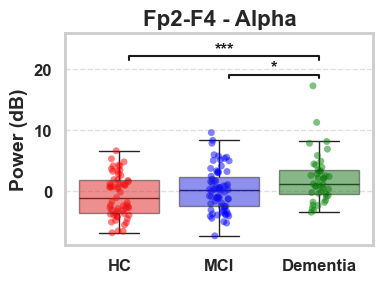

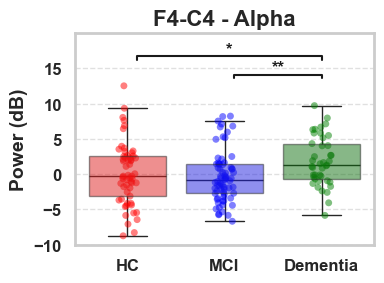

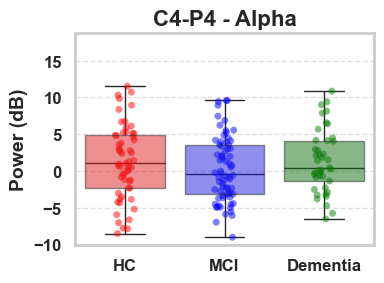

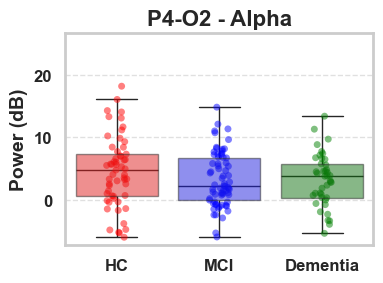

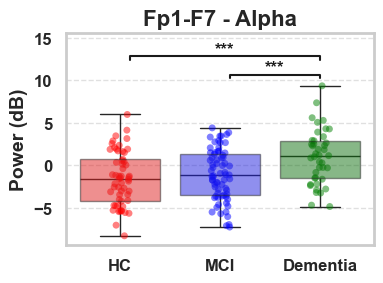

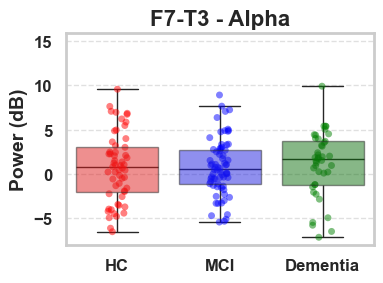

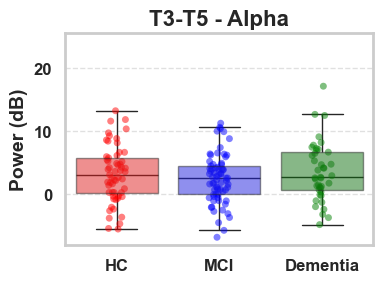

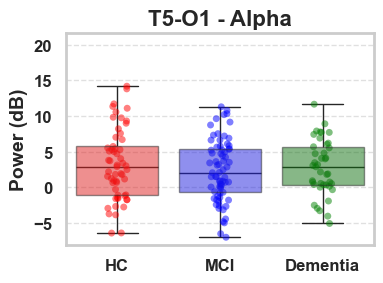

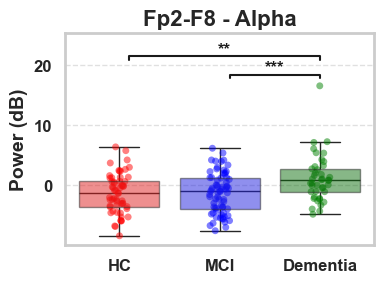

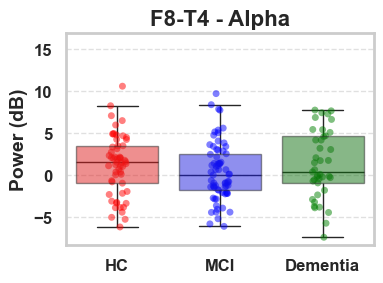

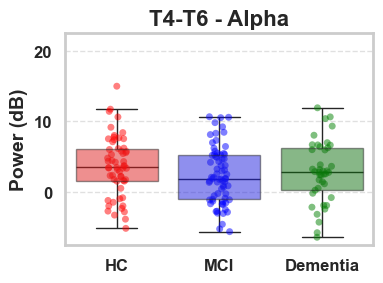

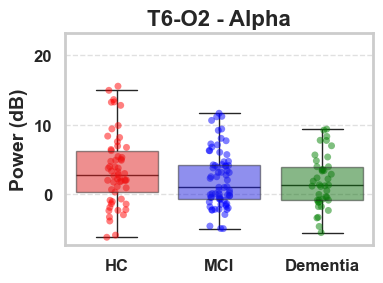

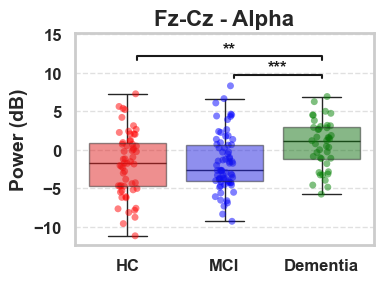

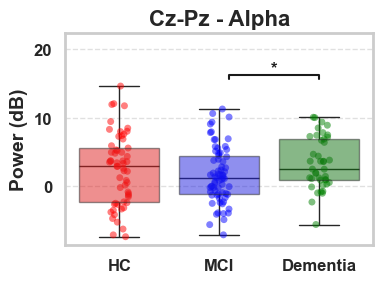

In [44]:
import seaborn as sns
import pandas as pd

output_folder = 'Boxplots'
os.makedirs(output_folder, exist_ok=True)

for band in bands.keys():
    for ch in HC_mean_sd[band].keys():
        
        plt.figure(figsize=(4, 3))

        df = pd.DataFrame({
            'Group': ['HC'] * len(HC_band_powers[band][ch]) + 
                     ['MCI'] * len(MCI_band_powers[band][ch]) + 
                     ['Dementia'] * len(AD_band_powers[band][ch]),
            'Power (dB)': HC_band_powers[band][ch] + 
                          MCI_band_powers[band][ch] + 
                          AD_band_powers[band][ch]
        })

        palette = {'HC': 'red',
                    'MCI': 'blue',
                    'Dementia': 'green'
                    }
        
        sns.stripplot(x='Group', y='Power (dB)', data=df,
              jitter=True,
              hue='Group',   
              palette=palette,
              dodge=False,  
              alpha=0.5)
        
        sns.boxplot(x='Group', y='Power (dB)', data=df,
                    hue='Group',             
                    legend=False,
                    showcaps=True, boxprops={"zorder":10, 'alpha':0.5},
                    showfliers=False, whiskerprops={'linewidth':1},
                    palette=palette)


        comparisons = [('HC', 'MCI'), ('HC', 'Dementia'), ('MCI', 'Dementia')]
        x_labels = ['HC', 'MCI', 'Dementia']

        ymax = df['Power (dB)'].max()
        y_offset = (df['Power (dB)'].max() - df['Power (dB)'].min()) * 0.05  

        heights = {
            ('HC', 'MCI'): ymax + y_offset,
            ('MCI', 'Dementia'): ymax + y_offset,
            ('HC', 'Dementia'): ymax + y_offset * 3.5
        }

        for (grp1, grp2) in comparisons:
            data1 = df[df['Group']==grp1]['Power (dB)']
            data2 = df[df['Group']==grp2]['Power (dB)']
            t_stat, p_value = ttest_ind(data1, data2)

            x1 = x_labels.index(grp1) + 0.1
            x2 = x_labels.index(grp2)
            y, h, col = heights[(grp1, grp2)], y_offset * 0.5, 'k'

            if p_value < 0.0001:
                text = '****'
            elif p_value < 0.001:
                text = '***'
            elif p_value < 0.01:
                text = '**'
            elif p_value < 0.05:
                text = '*'
            else:
                text = 'ns'

            if text != 'ns':
                plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
                plt.text((x1+x2)*.5, y+h, text, ha='center', va='bottom', color=col, fontsize=12, fontweight='bold')


        plt.title(f'{ch[4:]} - {band}', fontsize=16, fontweight='bold')
        plt.ylabel('Power (dB)', fontsize=14, fontweight='bold')
        plt.xlabel('')
        plt.xticks(fontsize=12, fontweight='bold')
        plt.yticks(fontsize=12, fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.6)

        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
        ax.tick_params(width=2.0, length=6.0)

        ymax = df['Power (dB)'].max()
        highest_bracket = ymax + y_offset * 6
          
        plt.ylim(top = highest_bracket + y_offset)
        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, f'{ch[4:]}_{band}_boxplot.svg'), format='svg')
        plt.show()
        plt.close()


## Alpha峰值頻率

In [45]:
from scipy.ndimage import uniform_filter1d

def calculate_cgf(psd_values, freqs, alpha_range=(4, 12)):
    psd_values = uniform_filter1d(psd_values, size=5)
    alpha_idx = np.where((freqs >= alpha_range[0]) & (freqs <= alpha_range[1]))[0]
    alpha_psd = psd_values[alpha_idx]
    cgf = np.sum(freqs[alpha_idx] * alpha_psd) / np.sum(alpha_psd)
    return cgf

def calculate_paf(psd_values, freqs, alpha_range=(4, 12)):
    psd_values = uniform_filter1d(psd_values, size=5)
    alpha_idx = np.where((freqs >= alpha_range[0]) & (freqs <= alpha_range[1]))[0]
    alpha_psd = psd_values[alpha_idx]
    peak_idx = np.argmax(alpha_psd)  # 找到最大值的位置
    paf = freqs[alpha_idx][peak_idx]  # 對應的頻率即為PAF
    return paf

def calculate_af_amplitude(psd_values, freqs, af):
    psd_values = np.array(psd_values)
    af_amplitude = np.interp(af, freqs, psd_values) 
    return af_amplitude


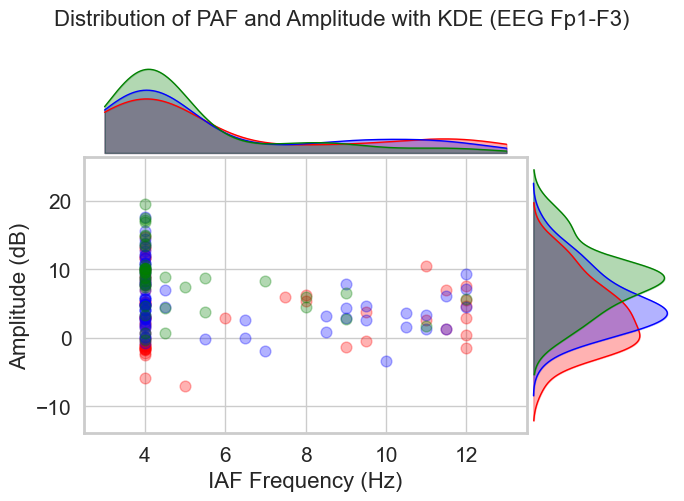

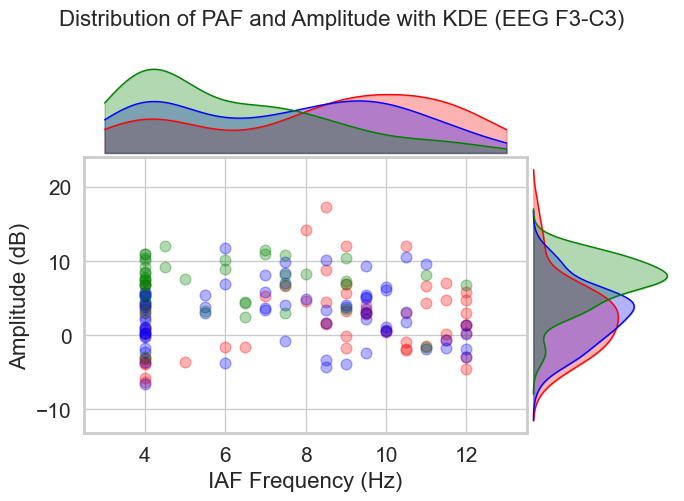

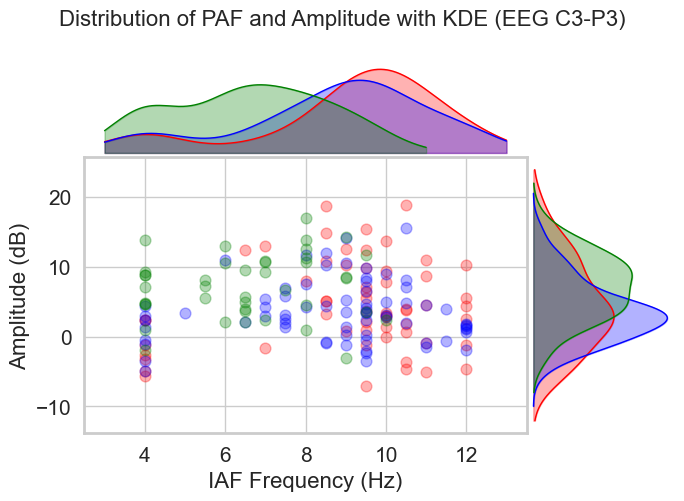

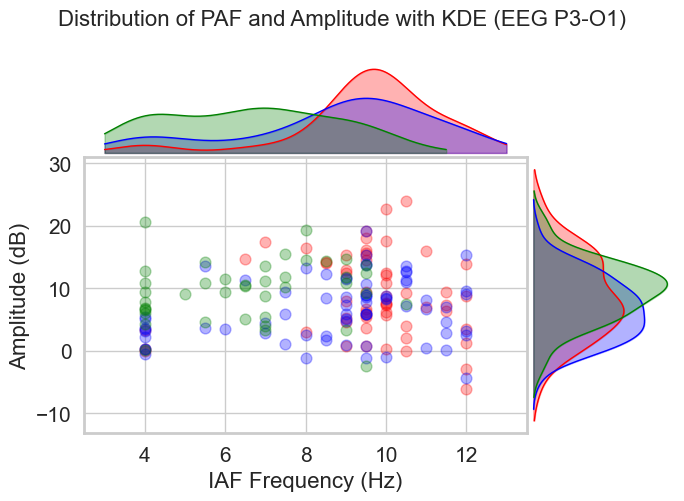

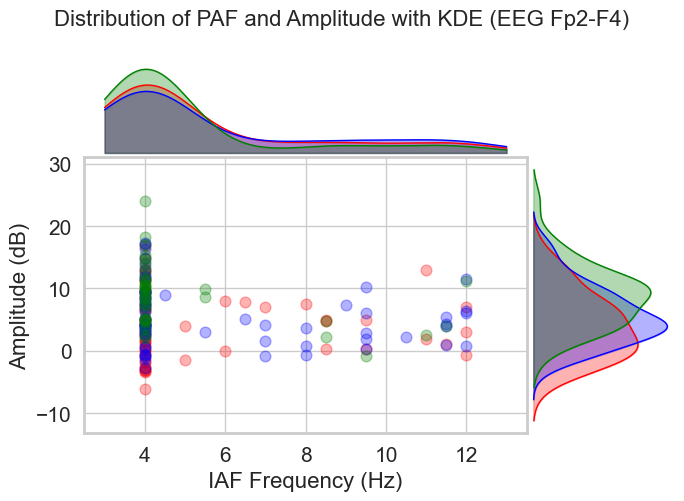

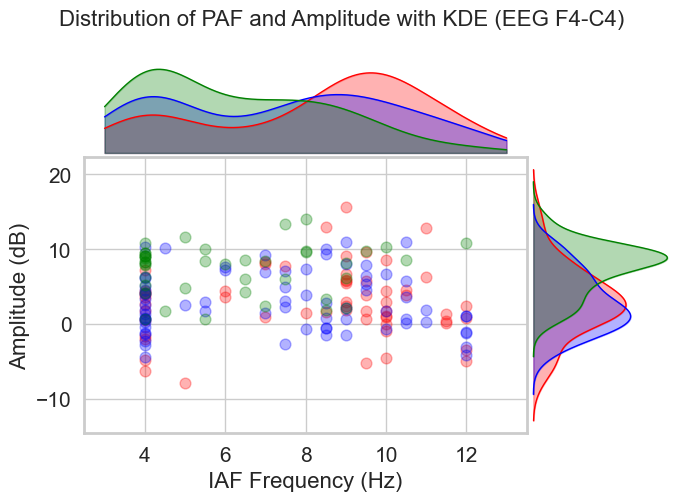

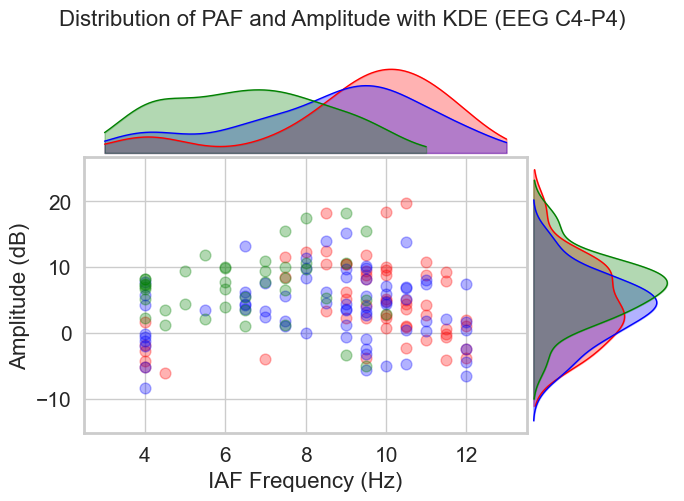

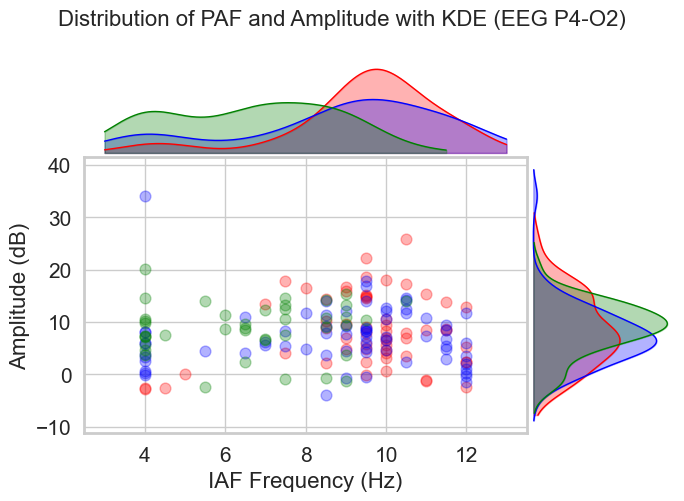

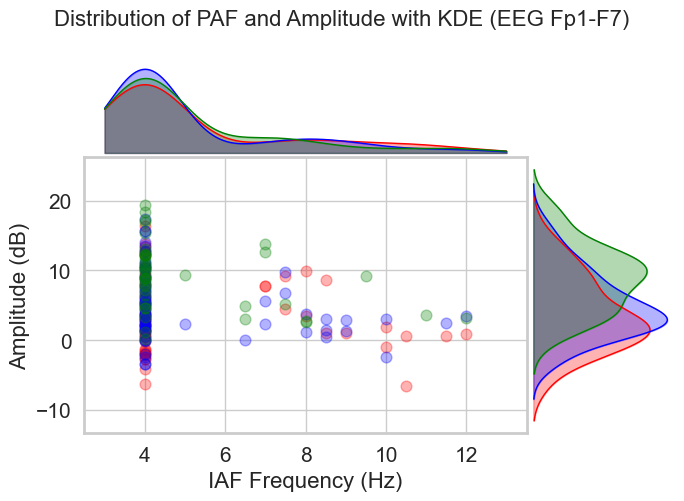

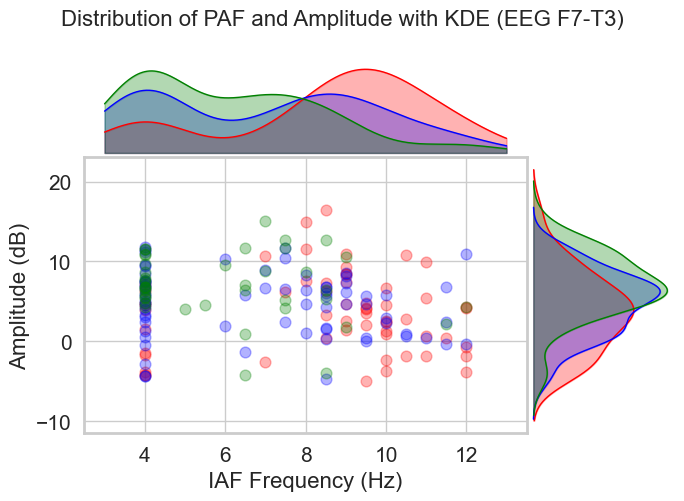

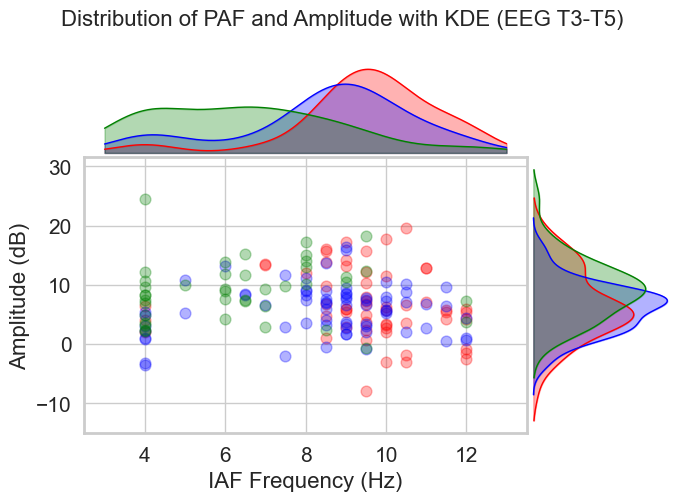

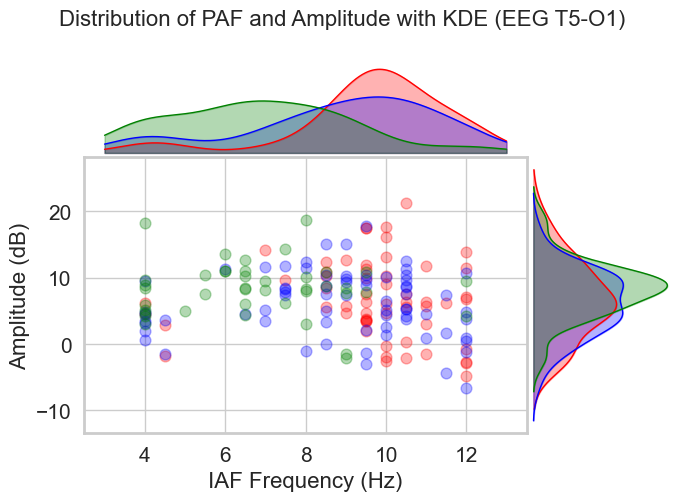

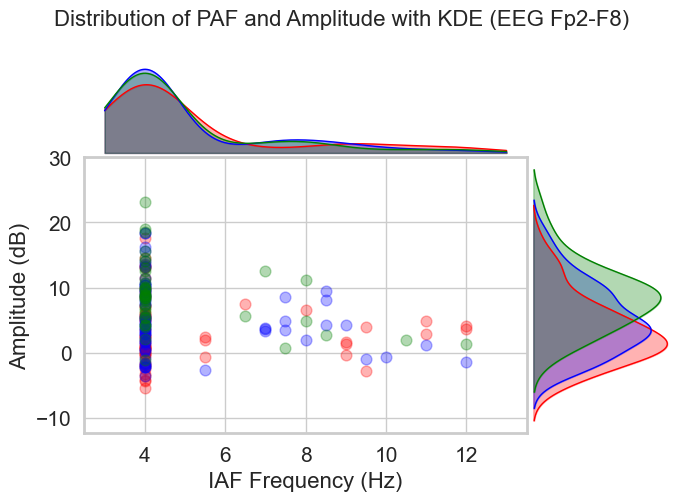

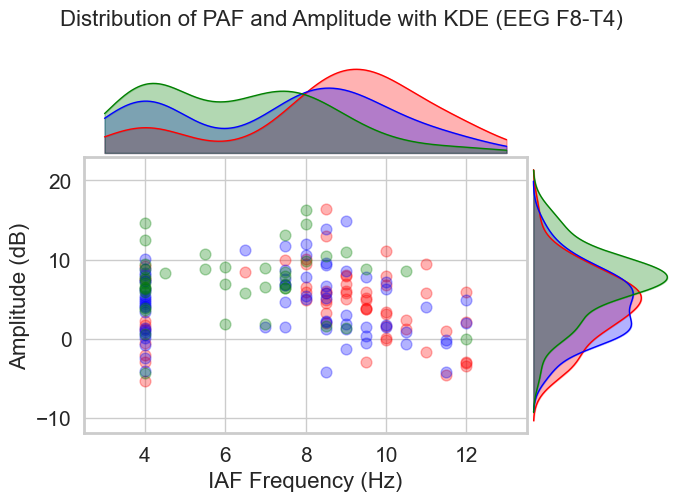

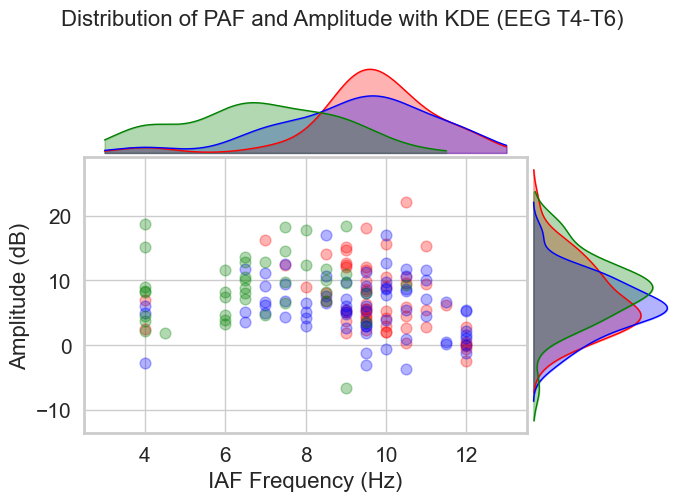

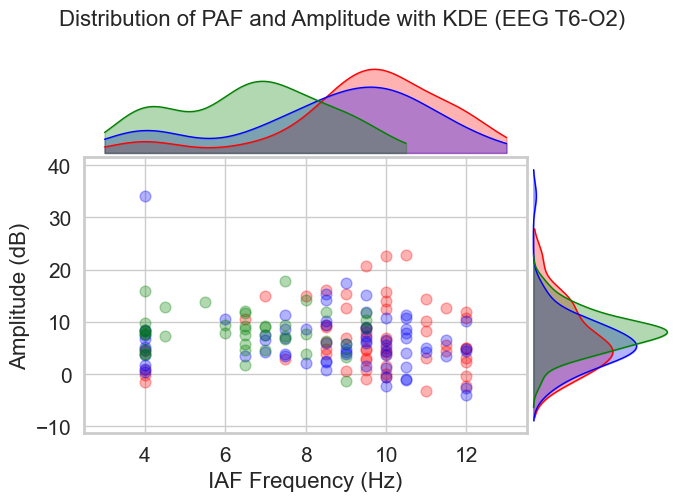

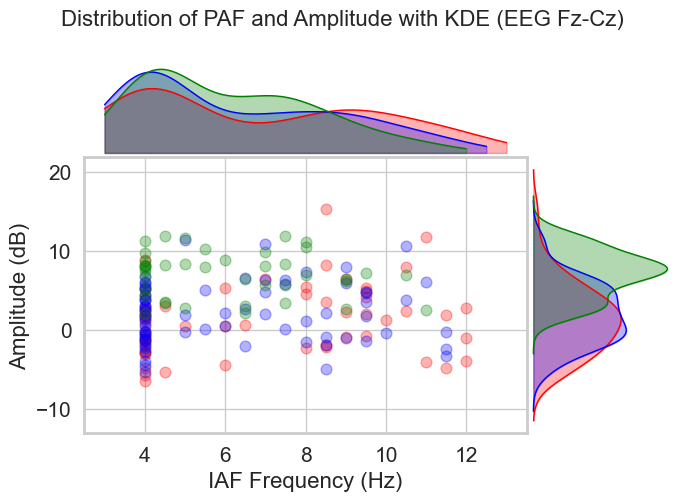

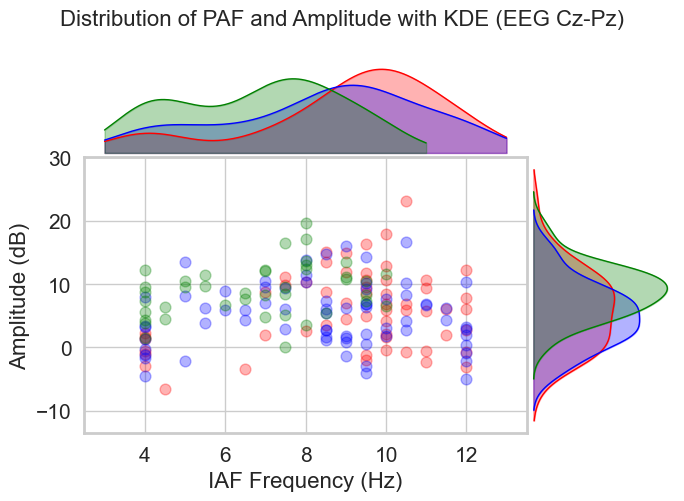

In [46]:
def plot_combined_iaf_distribution_with_clean_kde(HC_psd, MCI_psd, AD_psd, freqs, channel_name, ylim=None, xlim=None):
    from scipy.stats import gaussian_kde
    import matplotlib.gridspec as gridspec

    groups = {'HC': HC_psd, 'MCI': MCI_psd, 'AD': AD_psd}
    colors = {'HC': 'red', 'MCI': 'blue', 'AD': 'green'}

    # 創建主圖和 KDE 曲線的布局
    fig = plt.figure(figsize=(7, 5))
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0, wspace=0)

    # 主散布圖
    ax_scatter = fig.add_subplot(gs[1:, :-1])
    ax_kdex = fig.add_subplot(gs[0, :-1], sharex=ax_scatter)  # 頻率的 KDE 曲線
    ax_kdey = fig.add_subplot(gs[1:, -1], sharey=ax_scatter)  # 振幅的 KDE 曲線

    all_iaf_freqs = {}
    all_iaf_amplitudes = {}

    for group_name, group_data in groups.items():
        iaf_freqs = []
        iaf_amplitudes = []

        for psd in group_data:
            psd_channel = np.array(psd[channel_name])
            iaf = calculate_paf(psd_channel, freqs)  # 計算 PAF 頻率
            iaf_amplitude = calculate_af_amplitude(psd_channel, freqs, iaf)  # 計算振幅值
            iaf_amplitude = 10 * np.log10(iaf_amplitude)
            iaf_freqs.append(iaf)
            iaf_amplitudes.append(iaf_amplitude)

        all_iaf_freqs[group_name] = iaf_freqs
        all_iaf_amplitudes[group_name] = iaf_amplitudes

        display_name = 'Dementia' if group_name == 'AD' else group_name
        # 在主圖上繪製散布圖
        ax_scatter.scatter(iaf_freqs, iaf_amplitudes, alpha=0.3, label=f'{display_name}', color=colors[group_name], s=60)

        # KDE 曲線和填充區域
        kde_freqs = gaussian_kde(iaf_freqs)
        kde_amplitudes = gaussian_kde(iaf_amplitudes)

        freq_range = np.linspace(min(iaf_freqs) - 1, max(iaf_freqs) + 1, 500)
        amplitude_range = np.linspace(min(iaf_amplitudes) - 5, max(iaf_amplitudes) + 5, 500)

        ax_kdex.fill_between(freq_range, kde_freqs(freq_range), color=colors[group_name], alpha=0.3)
        ax_kdey.fill_betweenx(amplitude_range, kde_amplitudes(amplitude_range), color=colors[group_name], alpha=0.3)

        ax_kdex.plot(freq_range, kde_freqs(freq_range), color=colors[group_name], linewidth=1)
        ax_kdey.plot(kde_amplitudes(amplitude_range), amplitude_range, color=colors[group_name], linewidth=1)
    
    # 清除 KDE 曲線的軸和框架
    ax_kdex.axis('off')  # 關閉 X 軸 KDE 曲線的軸和框架
    ax_kdey.axis('off')  # 關閉 Y 軸 KDE 曲線的軸和框架

    # 設置 x, y 軸範圍
    if ylim is not None: ax_scatter.set_ylim(ylim)
    if xlim is not None: ax_scatter.set_xlim(xlim)

    # 主圖設置
    ax_scatter.set_xlabel('IAF Frequency (Hz)', fontsize=16)
    ax_scatter.set_ylabel('Amplitude (dB)', fontsize=16)
    ax_scatter.tick_params(axis='both', which='major', labelsize=15, width=2, length=6)

    for spine in ax_scatter.spines.values():
        spine.set_linewidth(2)

    # 添加標題
    fig.suptitle(f'Distribution of PAF and Amplitude with KDE ({channel_name})', fontsize=16, y=1)
    plt.tight_layout()
    file_name = f'IAF_Amplitude_KDE_{channel_name}.svg'
    file_path = os.path.join(output_folder, file_name)
    fig.savefig(file_path, format='svg')
    plt.show()

for channel_name in list(HC_psd[0].keys()): 
    plot_combined_iaf_distribution_with_clean_kde(HC_psd, MCI_psd, AD_psd, freqs, channel_name) 

## 重心頻率

In [47]:
import numpy as np
from scipy.ndimage import uniform_filter1d

def calculate_center_of_gravity(psd_values, freqs, freq_range=(4, 12), smooth_size=5):
    # 1. 數據平滑處理 (減少雜訊干擾)
    smoothed_psd = uniform_filter1d(psd_values, size=smooth_size)
    
    # 2. 篩選出目標頻段的索引
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    target_freqs = freqs[mask]
    target_psd = smoothed_psd[mask]
    
    # 3. 檢查範圍內是否有數據，避免除以零
    if np.sum(target_psd) == 0:
        return np.nan
    
    # 4. 計算重心頻率 (加權平均)
    cgf = np.sum(target_freqs * target_psd) / np.sum(target_psd)
    
    return cgf

# 如果你需要對應的振幅 (Amplitude at CGF)
def get_amplitude_at_freq(psd_values, freqs, target_f):
    return np.interp(target_f, freqs, psd_values)

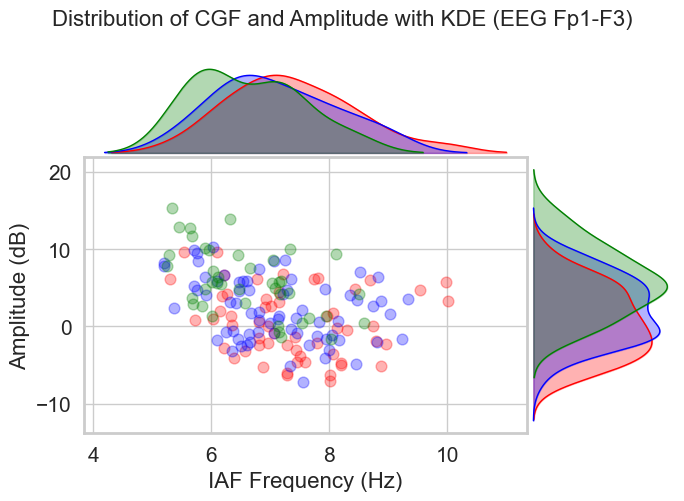

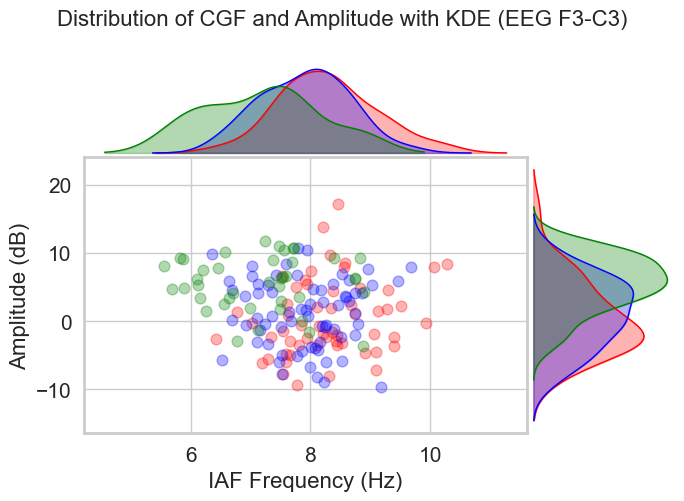

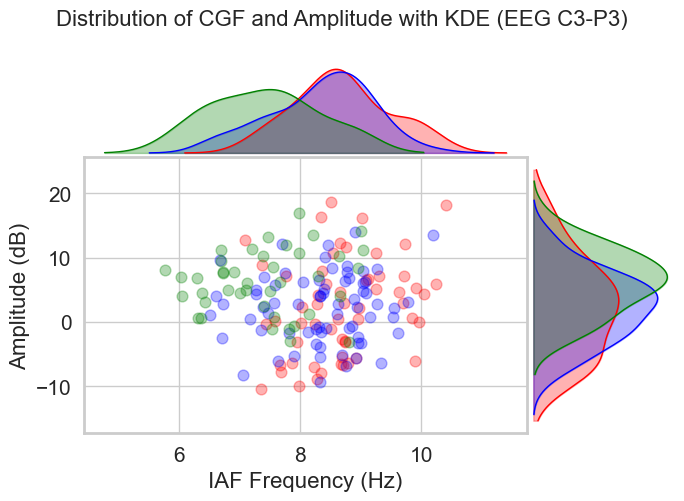

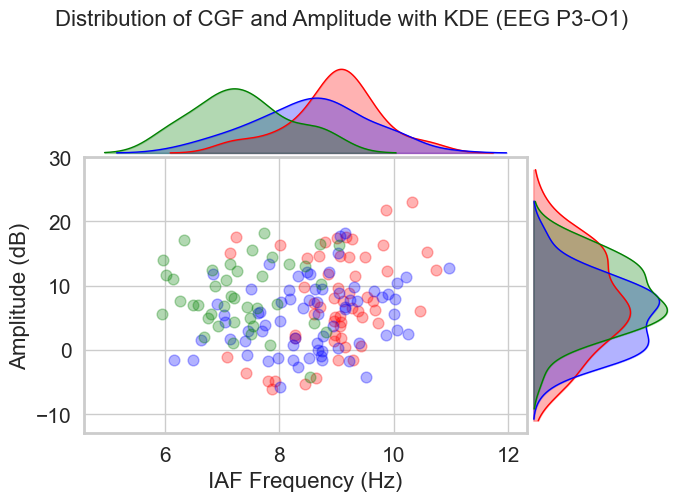

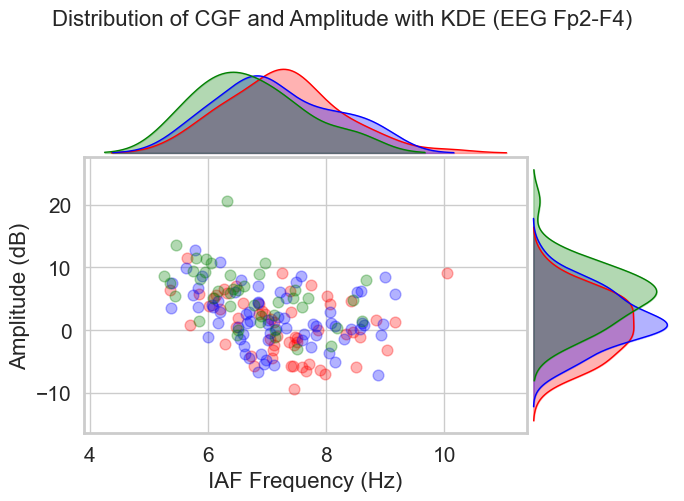

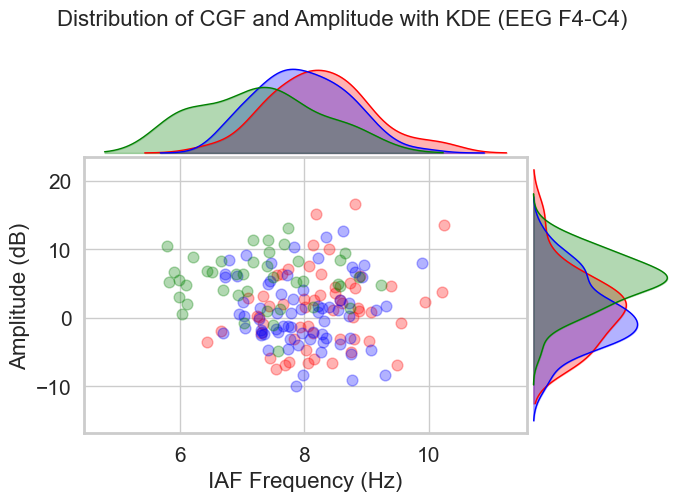

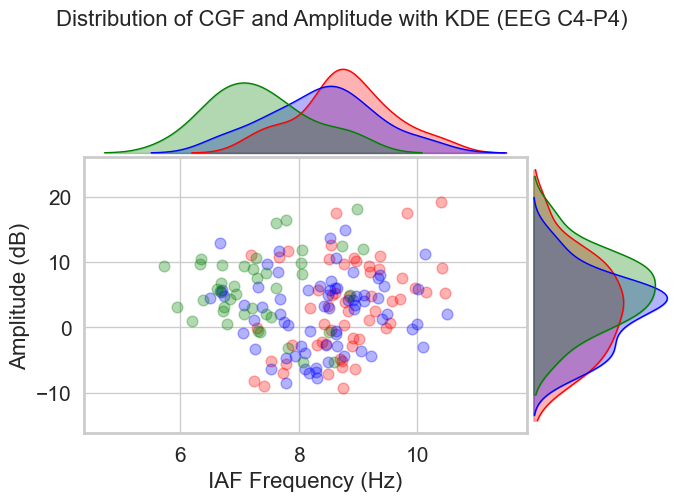

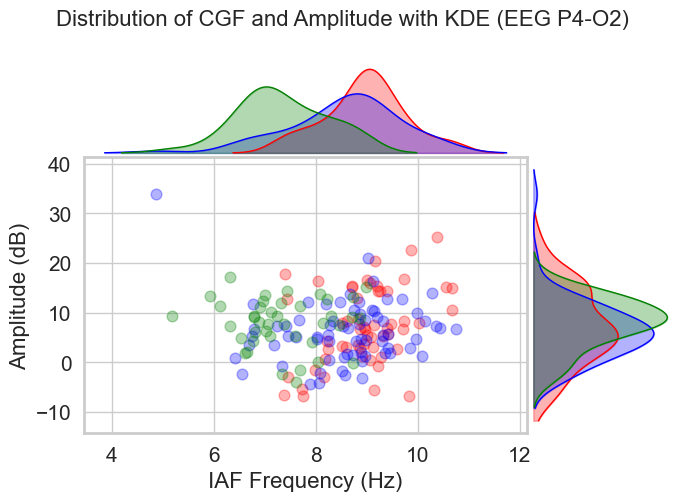

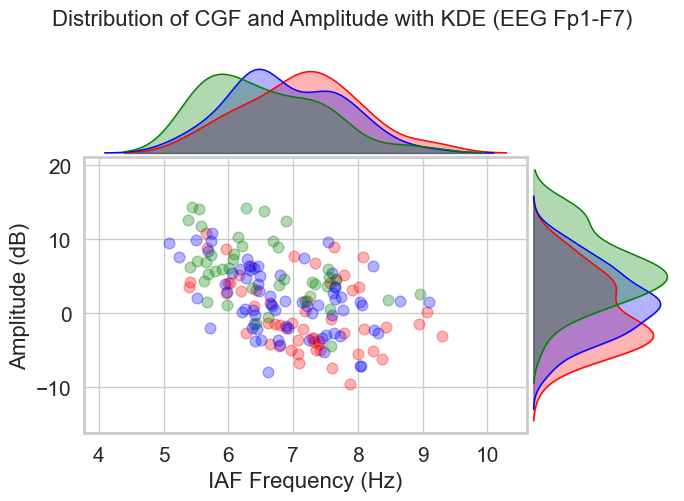

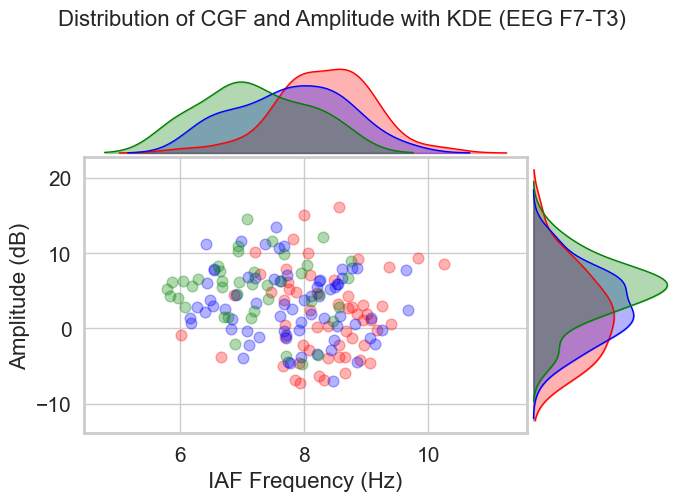

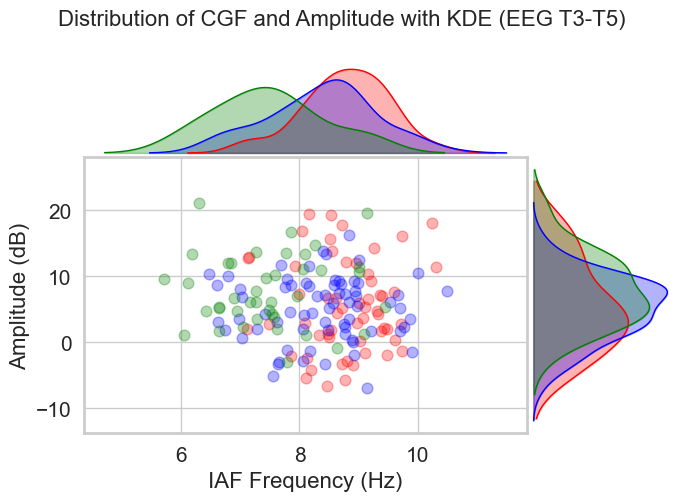

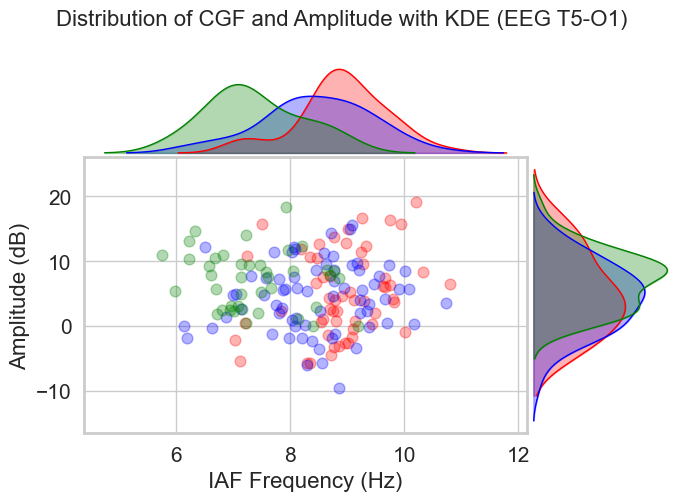

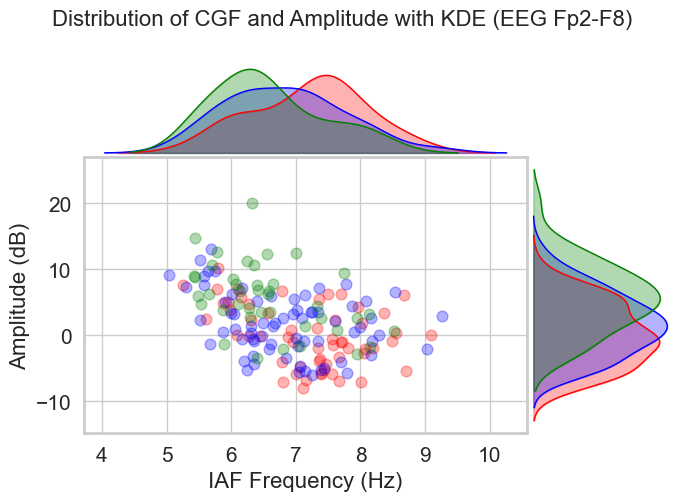

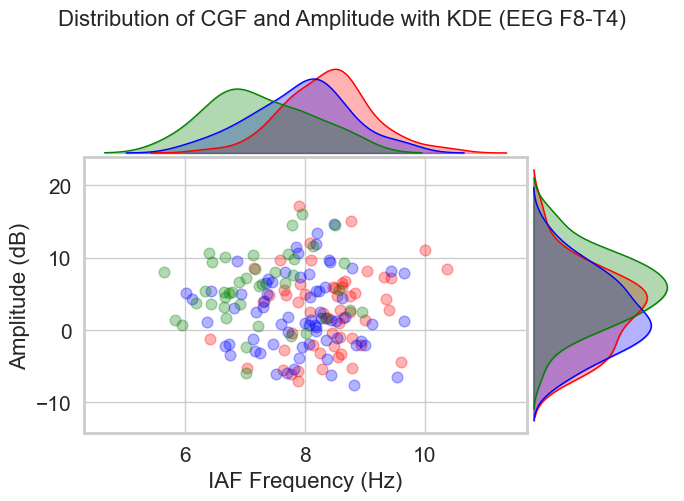

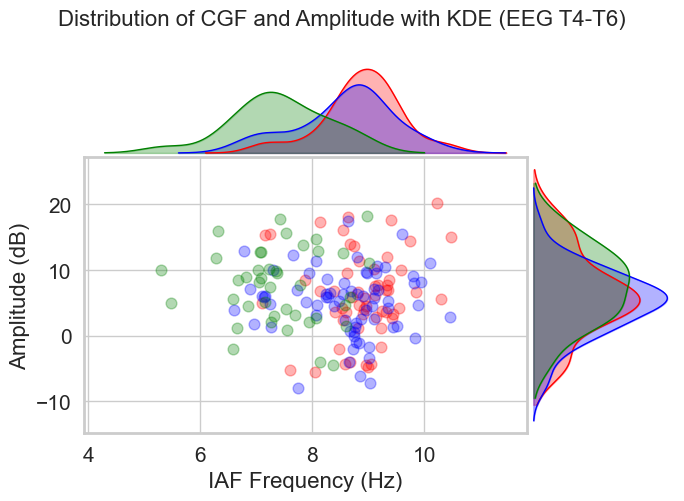

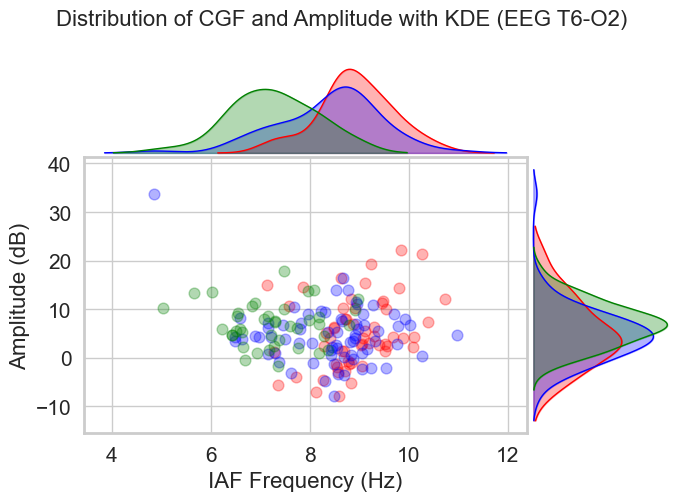

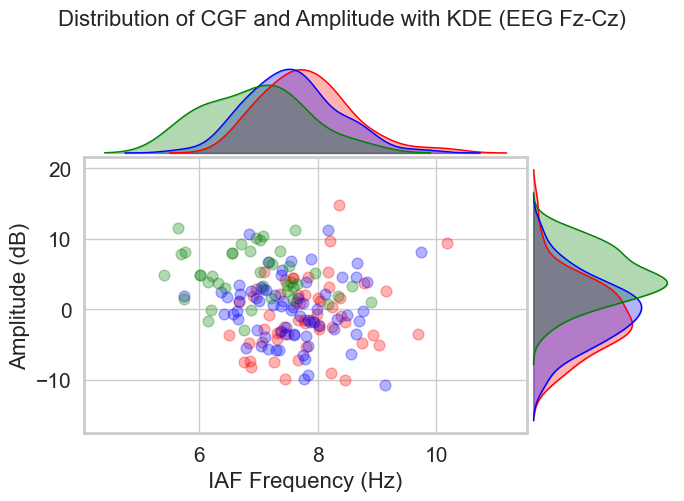

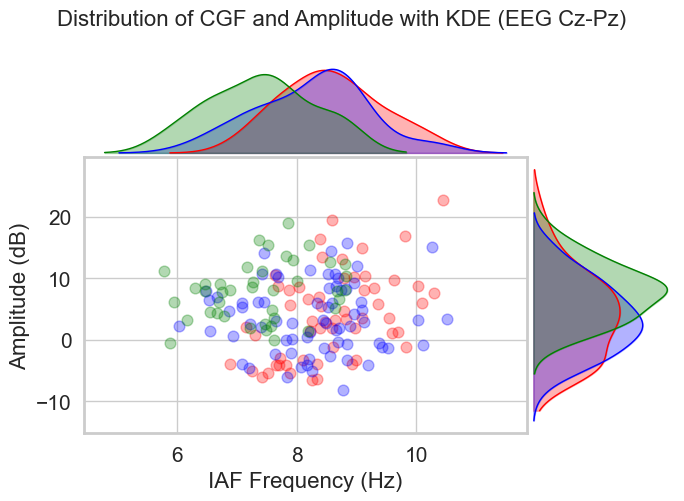

In [48]:
def plot_combined_iaf_distribution_with_clean_kde(HC_psd, MCI_psd, AD_psd, freqs, channel_name, ylim=None, xlim=None):
    from scipy.stats import gaussian_kde
    import matplotlib.gridspec as gridspec

    groups = {'HC': HC_psd, 'MCI': MCI_psd, 'AD': AD_psd}
    colors = {'HC': 'red', 'MCI': 'blue', 'AD': 'green'}

    # 創建主圖和 KDE 曲線的布局
    fig = plt.figure(figsize=(7, 5))
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0, wspace=0)

    # 主散布圖
    ax_scatter = fig.add_subplot(gs[1:, :-1])
    ax_kdex = fig.add_subplot(gs[0, :-1], sharex=ax_scatter)  # 頻率的 KDE 曲線
    ax_kdey = fig.add_subplot(gs[1:, -1], sharey=ax_scatter)  # 振幅的 KDE 曲線

    all_iaf_freqs = {}
    all_iaf_amplitudes = {}

    for group_name, group_data in groups.items():
        iaf_freqs = []
        iaf_amplitudes = []

        for psd in group_data:
            psd_channel = np.array(psd[channel_name])
            iaf = calculate_cgf(psd_channel, freqs)  # 計算 CGF 頻率
            #iaf = calculate_paf(psd_channel, freqs)  # 計算 PAF 頻率
            iaf_amplitude = calculate_af_amplitude(psd_channel, freqs, iaf)  # 計算振幅值
            iaf_amplitude = 10 * np.log10(iaf_amplitude)
            iaf_freqs.append(iaf)
            iaf_amplitudes.append(iaf_amplitude)

        all_iaf_freqs[group_name] = iaf_freqs
        all_iaf_amplitudes[group_name] = iaf_amplitudes

        display_name = 'Dementia' if group_name == 'AD' else group_name
        # 在主圖上繪製散布圖
        ax_scatter.scatter(iaf_freqs, iaf_amplitudes, alpha=0.3, label=f'{display_name}', color=colors[group_name], s=60)

        # KDE 曲線和填充區域
        kde_freqs = gaussian_kde(iaf_freqs)
        kde_amplitudes = gaussian_kde(iaf_amplitudes)

        freq_range = np.linspace(min(iaf_freqs) - 1, max(iaf_freqs) + 1, 500)
        amplitude_range = np.linspace(min(iaf_amplitudes) - 5, max(iaf_amplitudes) + 5, 500)

        ax_kdex.fill_between(freq_range, kde_freqs(freq_range), color=colors[group_name], alpha=0.3)
        ax_kdey.fill_betweenx(amplitude_range, kde_amplitudes(amplitude_range), color=colors[group_name], alpha=0.3)

        ax_kdex.plot(freq_range, kde_freqs(freq_range), color=colors[group_name], linewidth=1)
        ax_kdey.plot(kde_amplitudes(amplitude_range), amplitude_range, color=colors[group_name], linewidth=1)
    
    # 清除 KDE 曲線的軸和框架
    ax_kdex.axis('off')  # 關閉 X 軸 KDE 曲線的軸和框架
    ax_kdey.axis('off')  # 關閉 Y 軸 KDE 曲線的軸和框架

    # 設置 x, y 軸範圍
    if ylim is not None: ax_scatter.set_ylim(ylim)
    if xlim is not None: ax_scatter.set_xlim(xlim)

    # 主圖設置
    ax_scatter.set_xlabel('IAF Frequency (Hz)', fontsize=16)
    ax_scatter.set_ylabel('Amplitude (dB)', fontsize=16)
    ax_scatter.tick_params(axis='both', which='major', labelsize=15, width=2, length=6)

    for spine in ax_scatter.spines.values():
        spine.set_linewidth(2)

    # 添加標題
    fig.suptitle(f'Distribution of CGF and Amplitude with KDE ({channel_name})', fontsize=16, y=1)
    plt.tight_layout()
    file_name = f'IAF_Amplitude_KDE_{channel_name}.svg'
    file_path = os.path.join(output_folder, file_name)
    fig.savefig(file_path, format='svg')
    plt.show()

for channel_name in list(HC_psd[0].keys()): 
    plot_combined_iaf_distribution_with_clean_kde(HC_psd, MCI_psd, AD_psd, freqs, channel_name) 

## 複雜度HDF

In [49]:
import numpy as np

def calculate_hfd(data, k_max=10):
    """
    計算單一通道時域信號的 Higuchi Fractal Dimension (HFD)
    """
    N = len(data)
    L_k = np.zeros(k_max)
    
    for k in range(1, k_max + 1):
        Lk_m = []
        for m in range(k):
            # 建立子序列索引
            indices = np.arange(m, N, k)
            n_max = len(indices)
            
            if n_max > 1:
                # 計算相鄰點的絕對差值和
                # 公式: L_m(k) = [sum |X(i)-X(j)| * (N-1) / (n_max-1 * k)] / k
                diffs = np.abs(np.diff(data[indices]))
                l_m_k = (np.sum(diffs) * (N - 1) / ((n_max - 1) * k)) / k
                Lk_m.append(l_m_k)
        
        # 避免 Lk_m 為空導致 mean 報錯
        L_k[k-1] = np.mean(Lk_m) if Lk_m else 0

    # 移除可能存在的 0 或負值以進行 log 運算
    valid = L_k > 0
    if not np.any(valid): return np.nan
    
    x = np.log(1.0 / np.arange(1, k_max + 1)[valid])
    y = np.log(L_k[valid])
    
    # 線性擬合斜率即為 HFD
    hfd, _ = np.polyfit(x, y, 1)
    return hfd

def batch_calculate_hfd(path, event_name='Eyes Closed', delay_time=0, cut_time=8, k_max=10):
    """
    從資料夾讀取 EDF 並計算每個通道的 HFD 平均值
    """
    filesname = os.listdir(path)
    total_hfd_results = []
    filenames = []

    for filename in filesname:
        file_path = os.path.join(path, filename)
        try:
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            events, event_id = mne.events_from_annotations(raw, verbose=False)
            s_events = events[events[:, 2] == event_id[event_name]]
        except Exception:
            continue

        if 'Photic' in raw.info['ch_names']:
            raw.drop_channels(['Photic'])

        fs = int(raw.info['sfreq'])
        ch_names = raw.info['ch_names']
        
        # 儲存該受試者各通道多個 epoch 的 HFD
        subject_hfd_temp = {ch_name: [] for ch_name in ch_names}

        for s_event in s_events:
            start_sample = s_event[0] + int(fs * delay_time)
            end_sample = start_sample + int(fs * cut_time)

            if end_sample > len(raw): continue

            # 提取數據並濾波
            event_data, _ = raw[:, start_sample:end_sample]
            event_data_filtered = mne.filter.filter_data(event_data, sfreq=fs, l_freq=0.5, h_freq=50, verbose=False)

            for ch_idx, ch_name in enumerate(ch_names):
                hfd_val = calculate_hfd(event_data_filtered[ch_idx], k_max=k_max)
                subject_hfd_temp[ch_name].append(hfd_val)

        # 計算該受試者每個通道在所有 epoch 上的平均 HFD
        subject_mean_hfd = {ch_name: np.mean(vals) for ch_name, vals in subject_hfd_temp.items() if vals}
        
        if subject_mean_hfd:
            total_hfd_results.append(subject_mean_hfd)
            filenames.append(filename)

    return total_hfd_results, filenames

In [50]:
import pandas as pd
from scipy.stats import f_oneway

# --- 1. 計算 HFD (請根據你的實際路徑調整) ---
HC_hfd, HC_hfd_files = batch_calculate_hfd(path_hc)
MCI_hfd, MCI_hfd_files = batch_calculate_hfd(path_mci)
AD_hfd, AD_hfd_files = batch_calculate_hfd(path_ad)

# --- 2. 整理並列印所有 HFD 數值 ---
def convert_to_df(hfd_results, filenames, group_name):
    df = pd.DataFrame(hfd_results)
    df.insert(0, 'Filename', filenames)
    df.insert(1, 'Group', group_name)
    return df

df_hc = convert_to_df(HC_hfd, HC_hfd_files, 'HC')
df_mci = convert_to_df(MCI_hfd, MCI_hfd_files, 'MCI')
df_ad = convert_to_df(AD_hfd, AD_hfd_files, 'AD')

# 合併三組數據
all_hfd_df = pd.concat([df_hc, df_mci, df_ad], ignore_index=True)

print("\n" + "="*30)
print("  所有受試者各通道 HFD 數值表")
print("="*30)
# 使用 pd.set_option 確保可以看到所有欄位
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(all_hfd_df.to_string(index=False))

# --- 3. 進行所有通道的 ANOVA 檢定並列印 ---
print("\n" + "="*30)
print("  所有通道 ANOVA 統計檢定結果")
print("="*30)

# 獲取所有腦波通道名稱
channels = [col for col in all_hfd_df.columns if col not in ['Filename', 'Group']]
anova_summary = []

for ch in channels:
    # 提取三組數據並排除 NaN (確保統計正確)
    group_hc = all_hfd_df[all_hfd_df['Group'] == 'HC'][ch].dropna()
    group_mci = all_hfd_df[all_hfd_df['Group'] == 'MCI'][ch].dropna()
    group_ad = all_hfd_df[all_hfd_df['Group'] == 'AD'][ch].dropna()
    
    # 執行 ANOVA
    if len(group_hc) > 1 and len(group_mci) > 1 and len(group_ad) > 1:
        f_stat, p_val = f_oneway(group_hc, group_mci, group_ad)
        
        anova_summary.append({
            'Channel': ch,
            'F-Statistic': round(f_stat, 4),
            'p-value': round(p_val, 4),
            'Significant': 'YES (p<0.05)' if p_val < 0.05 else 'no'
        })

# 轉換成 DataFrame 並根據 p-value 排序（最顯著的排在前面）
anova_df = pd.DataFrame(anova_summary).sort_values(by='p-value')

print(anova_df.to_string(index=False))



  所有受試者各通道 HFD 數值表
    Filename Group  EEG Fp1-F3  EEG F3-C3  EEG C3-P3  EEG P3-O1  EEG Fp2-F4  EEG F4-C4  EEG C4-P4  EEG P4-O2  EEG Fp1-F7  EEG F7-T3  EEG T3-T5  EEG T5-O1  EEG Fp2-F8  EEG F8-T4  EEG T4-T6  EEG T6-O2  EEG Fz-Cz  EEG Cz-Pz
A7668316.edf    HC    1.590336   1.693137   1.585567   1.564979    1.564648   1.634568   1.569542   1.562651    1.567448   1.670542   1.565673   1.580982    1.697624   1.711269   1.571971   1.565352   1.568933   1.565063
B0400089.edf    HC    1.615830   1.844339   1.769861   1.711938    1.608822   1.840157   1.748499   1.695558    1.598847   1.739054   1.736167   1.689241    1.594782   1.769399   1.691169   1.677014   1.686140   1.726242
B0445163.edf    HC    1.827896   1.884840   1.830077   1.787002    1.716956   1.803387   1.827091   1.822821    1.725659   1.724802   1.741126   1.757488    1.676101   1.693132   1.765093   1.776231   1.813417   1.824451
B1949126.edf    HC    1.675371   1.783093   1.721112   1.682271    1.663648   1.770654   1.65503

In [51]:
# --- 4. 計算各組各通道的平均數與變異數 ---
print("\n" + "="*30)
print("  各組各通道 HFD 統計摘要 (平均數 & 變異數)")
print("="*30)

# 1. 執行分組計算
# 我們對 'Group' 分組，並對所有腦波通道 (channels) 套用 mean 和 var 函數
group_stats = all_hfd_df.groupby('Group')[channels].agg(['mean', 'var'])

# 2. 為了方便閱讀，我們可以將結果轉置 (Transpose) 
# 這樣列 (Rows) 會是通道，欄 (Columns) 會是各組的統計數值
group_stats_transposed = group_stats.T

# 3. 列印結果
print(group_stats_transposed)



  各組各通道 HFD 統計摘要 (平均數 & 變異數)
Group                  AD        HC       MCI
EEG Fp1-F3 mean  1.517331  1.481430  1.384391
           var   0.049709  0.044590  0.018961
EEG F3-C3  mean  1.473182  1.456077  1.360421
           var   0.058628  0.066922  0.036930
EEG C3-P3  mean  1.404146  1.382870  1.288657
           var   0.052559  0.071023  0.043865
EEG P3-O1  mean  1.380423  1.328330  1.247268
           var   0.044775  0.070868  0.042197
EEG Fp2-F4 mean  1.517723  1.462077  1.389928
           var   0.046305  0.039522  0.021548
EEG F4-C4  mean  1.475483  1.437700  1.358249
           var   0.048753  0.064293  0.037971
EEG C4-P4  mean  1.390415  1.369674  1.288792
           var   0.035236  0.073794  0.040761
EEG P4-O2  mean  1.354383  1.323474  1.249796
           var   0.037704  0.069141  0.038897
EEG Fp1-F7 mean  1.509092  1.460072  1.380495
           var   0.042605  0.037856  0.016177
EEG F7-T3  mean  1.549305  1.487999  1.413398
           var   0.053290  0.041402  0.034626
EEG 

In [52]:
print("all_hfd_df 裡面的欄位名稱：", [col for col in all_hfd_df.columns if col not in ['Filename', 'Group']])
print("anova_df 裡面的通道名稱：", anova_df['Channel'].tolist())

all_hfd_df 裡面的欄位名稱： ['EEG Fp1-F3', 'EEG F3-C3', 'EEG C3-P3', 'EEG P3-O1', 'EEG Fp2-F4', 'EEG F4-C4', 'EEG C4-P4', 'EEG P4-O2', 'EEG Fp1-F7', 'EEG F7-T3', 'EEG T3-T5', 'EEG T5-O1', 'EEG Fp2-F8', 'EEG F8-T4', 'EEG T4-T6', 'EEG T6-O2', 'EEG Fz-Cz', 'EEG Cz-Pz']
anova_df 裡面的通道名稱： ['EEG Fp1-F3', 'EEG Fp1-F7', 'EEG Fp2-F8', 'EEG Fp2-F4', 'EEG F7-T3', 'EEG Fz-Cz', 'EEG F8-T4', 'EEG T5-O1', 'EEG P3-O1', 'EEG F3-C3', 'EEG F4-C4', 'EEG C3-P3', 'EEG Cz-Pz', 'EEG T6-O2', 'EEG P4-O2', 'EEG T3-T5', 'EEG C4-P4', 'EEG T4-T6']


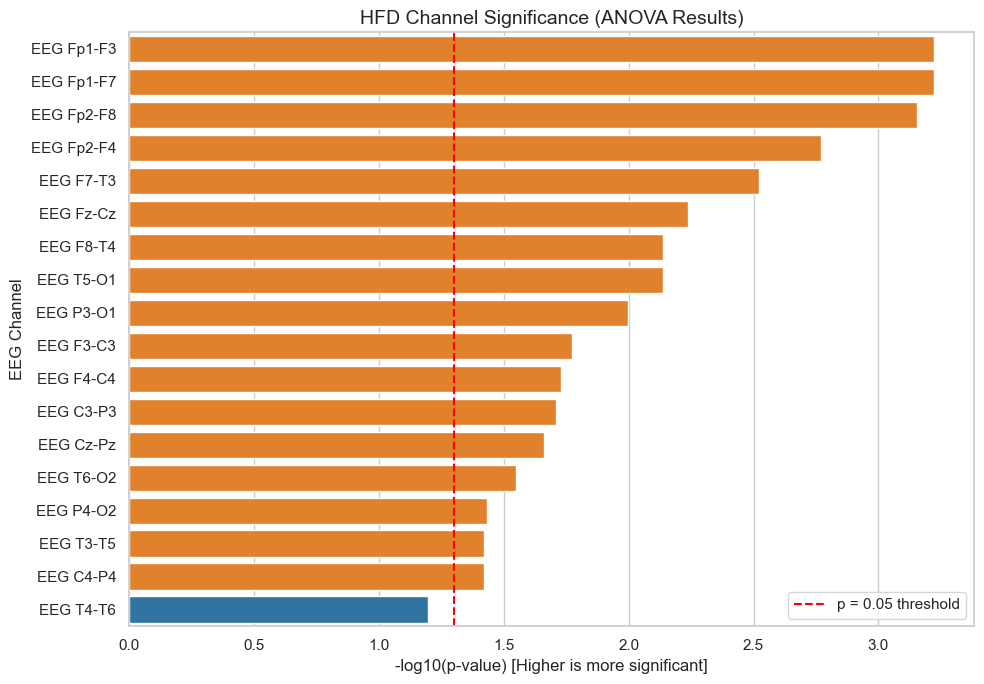

In [53]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 計算 -log10(p) 增加視覺對比度
anova_df['-log10(p)'] = -np.log10(anova_df['p-value'])

plt.figure(figsize=(10, 7))

# 2. 自動根據 p-value 設定顏色 (小於 0.05 或最接近的通道設為橘色)
# 這裡找尋 p-value 最小值作為標示標的
min_p = anova_df['p-value'].min()
colors = ['#ff7f0e' if p == min_p or p < 0.05 else '#1f77b4' for p in anova_df['p-value']]

# 3. 繪製圖表 (已修正 FutureWarning)
sns.barplot(x='-log10(p)', y='Channel', data=anova_df, 
            hue='Channel', palette=colors, legend=False)

# 4. 畫出 p=0.05 的標準線
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p = 0.05 threshold')

plt.title('HFD Channel Significance (ANOVA Results)', fontsize=14)
plt.xlabel('-log10(p-value) [Higher is more significant]', fontsize=12)
plt.ylabel('EEG Channel', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

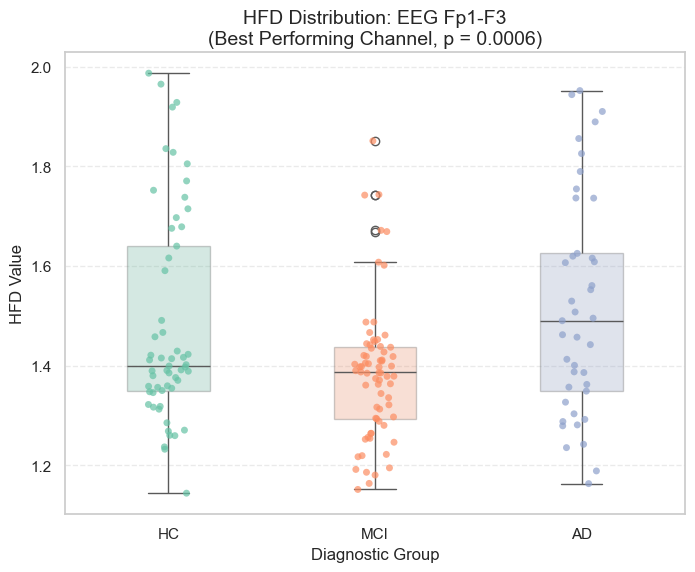

In [54]:
# 1. 自動取得 p-value 最小的通道名稱
best_channel = anova_df.iloc[0]['Channel']
best_p = anova_df.iloc[0]['p-value']

plt.figure(figsize=(8, 6))

# 2. 繪製盒狀圖 (已修正 FutureWarning)
sns.boxplot(x='Group', y=best_channel, data=all_hfd_df, 
            order=['HC', 'MCI', 'AD'], 
            hue='Group', palette='Set2', legend=False,
            width=0.4, boxprops=dict(alpha=0.3))

# 3. 疊加點狀圖
sns.stripplot(x='Group', y=best_channel, data=all_hfd_df, 
              order=['HC', 'MCI', 'AD'], 
              hue='Group', palette='Set2', legend=False,
              size=5, jitter=True, alpha=0.7)

plt.title(f'HFD Distribution: {best_channel}\n(Best Performing Channel, p = {best_p})', fontsize=14)
plt.ylabel('HFD Value', fontsize=12)
plt.xlabel('Diagnostic Group', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

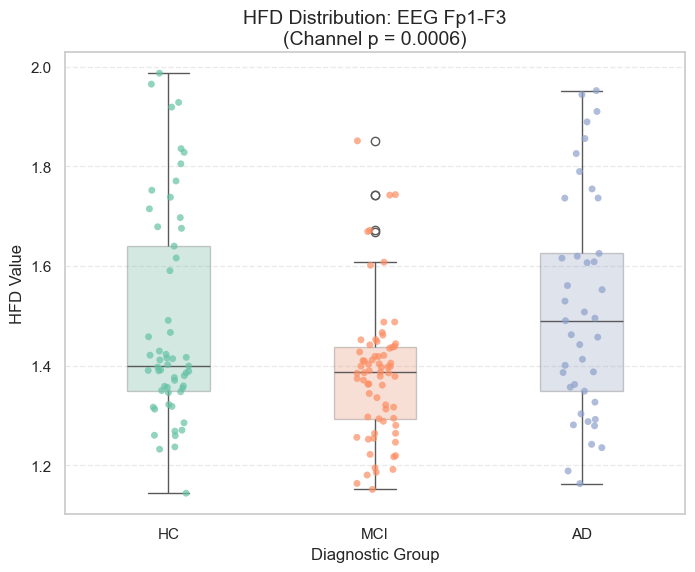

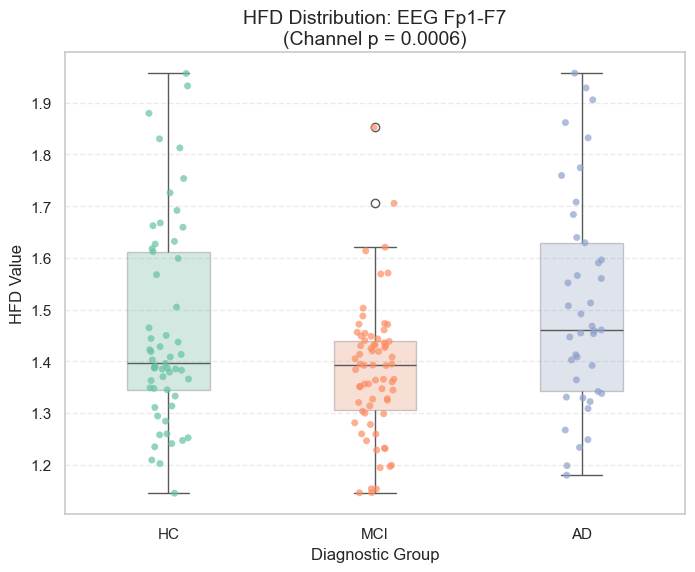

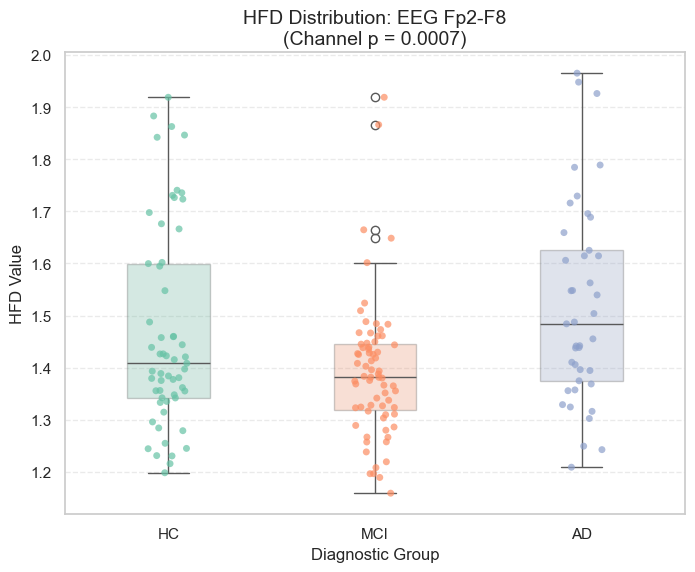

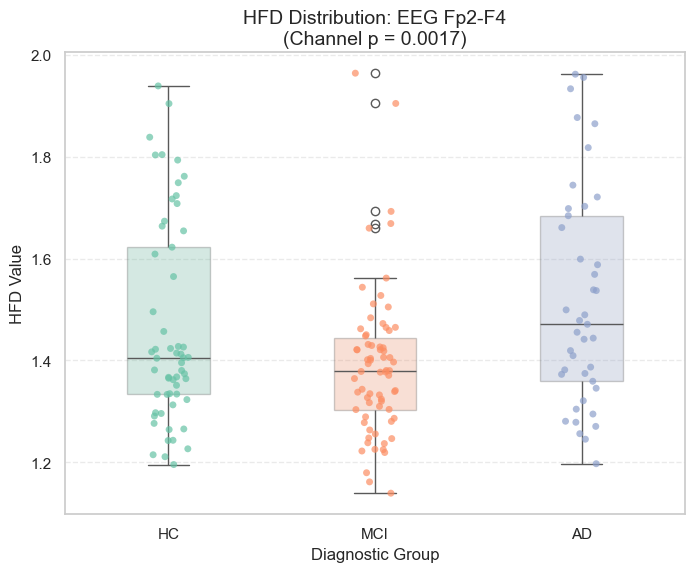

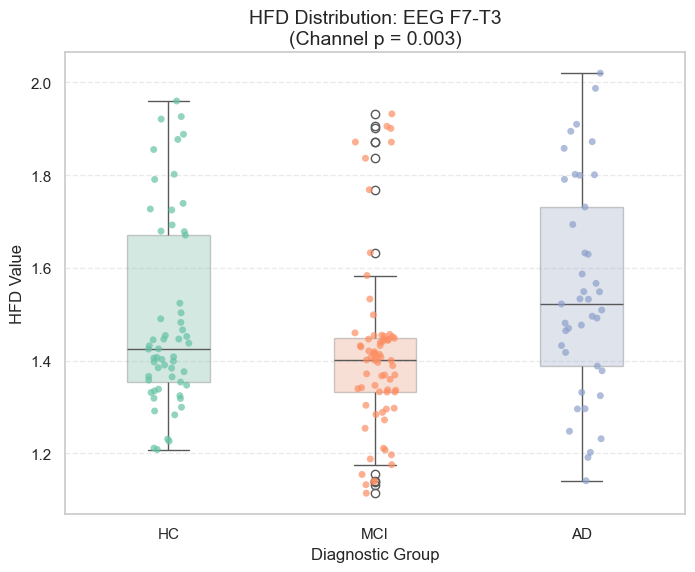

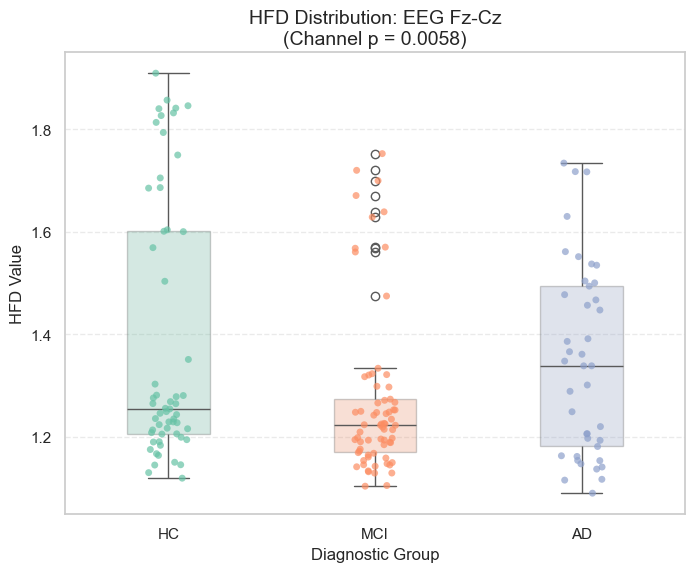

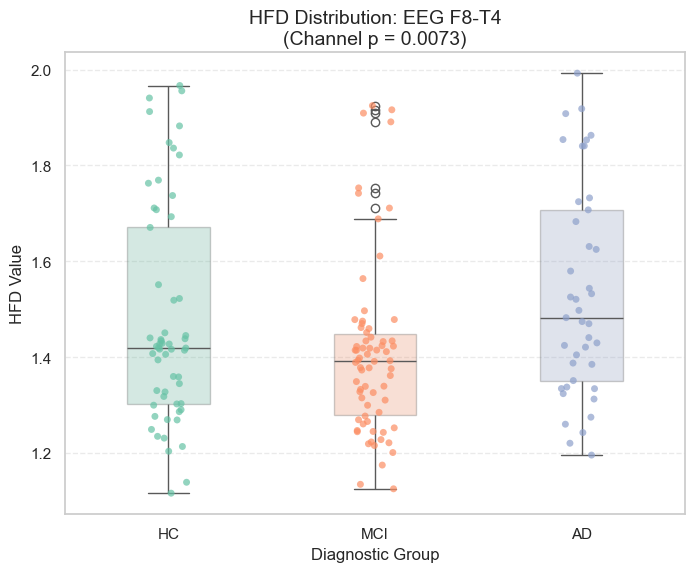

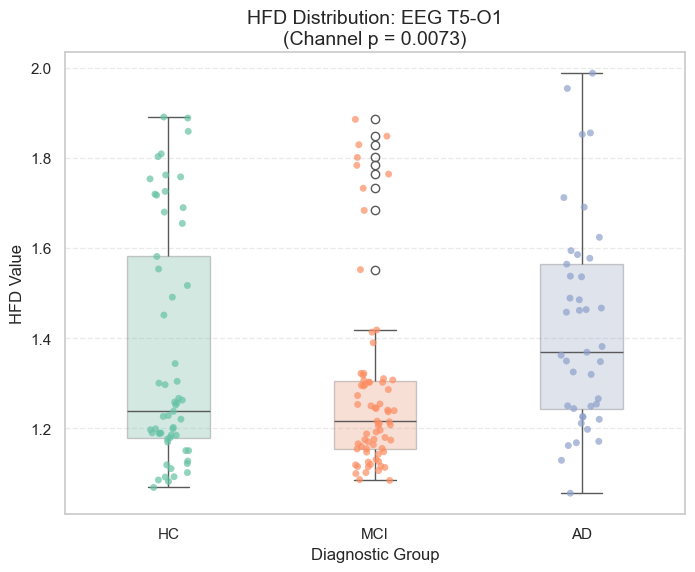

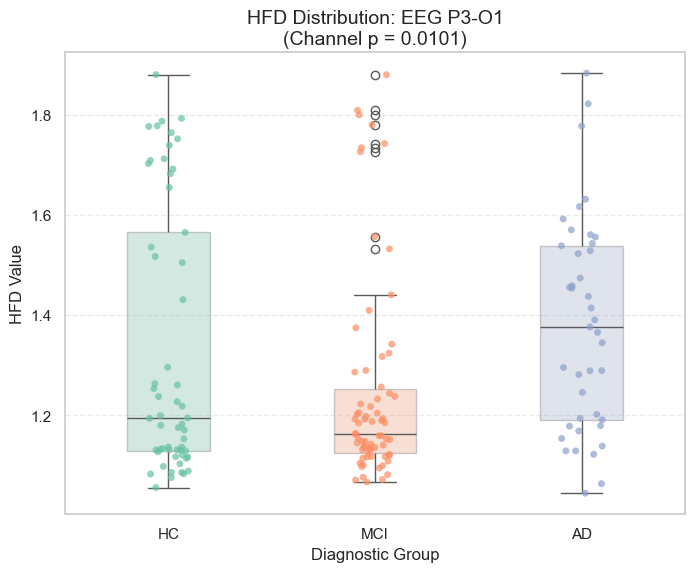

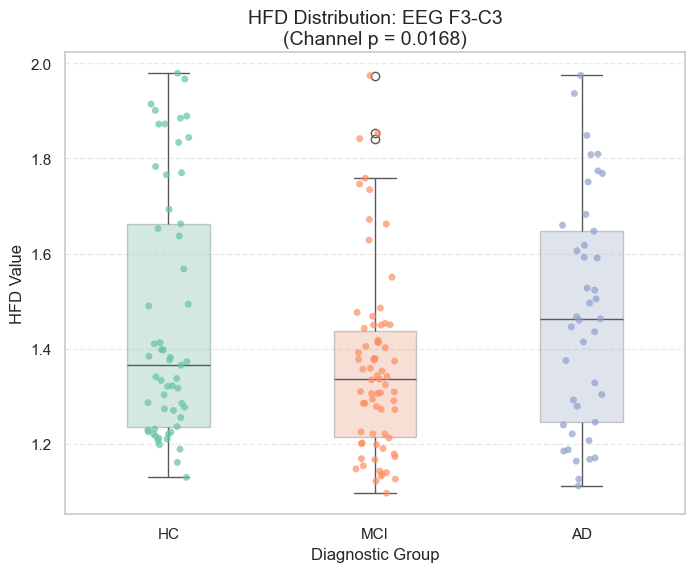

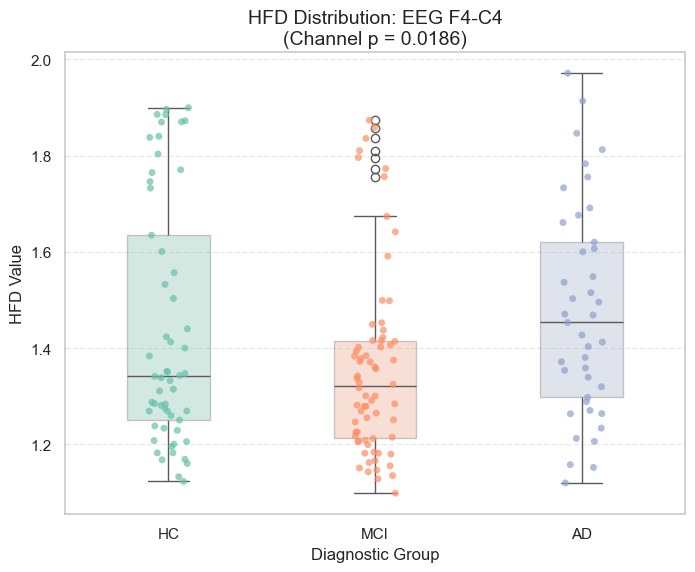

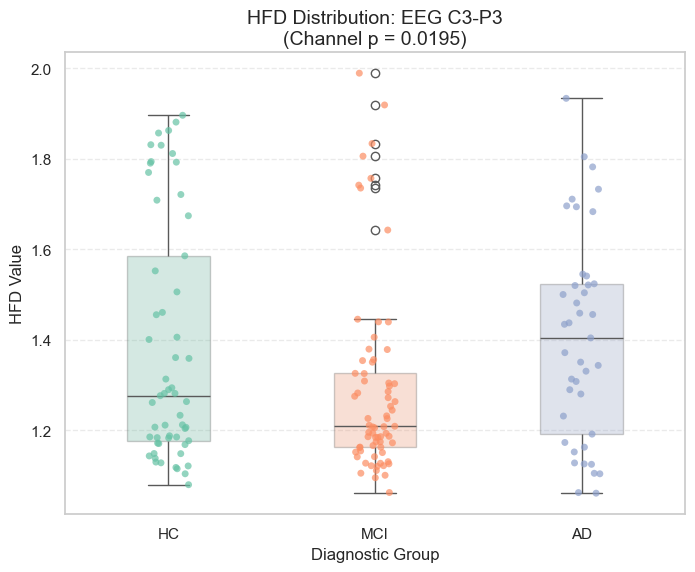

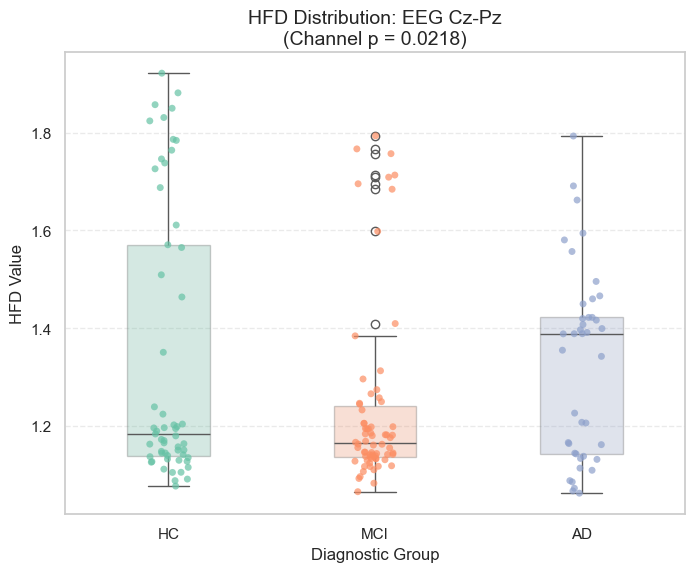

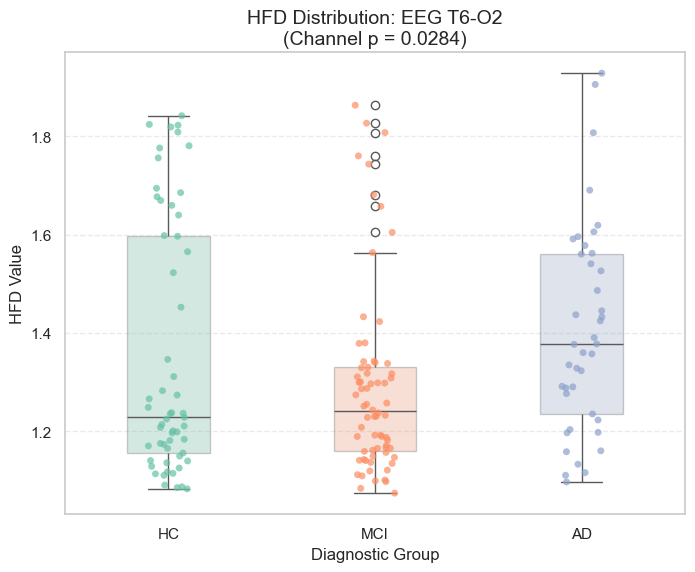

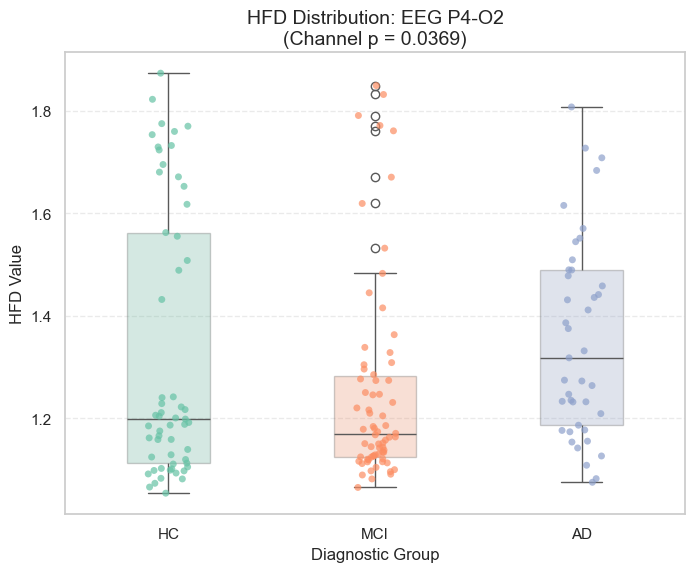

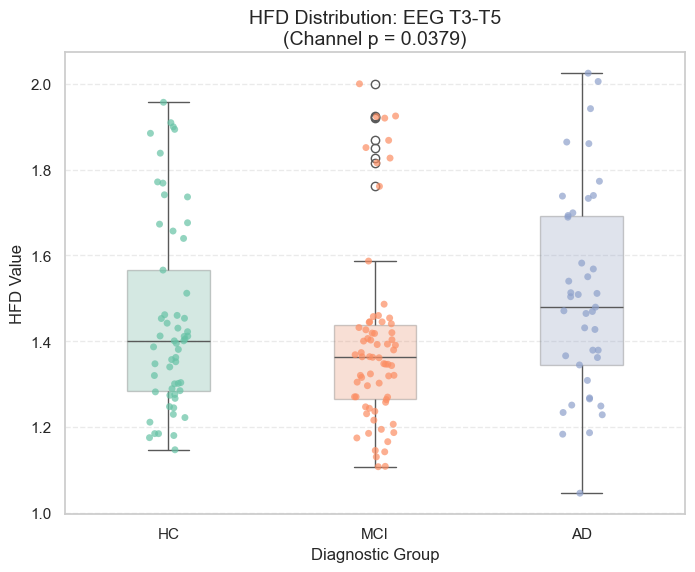

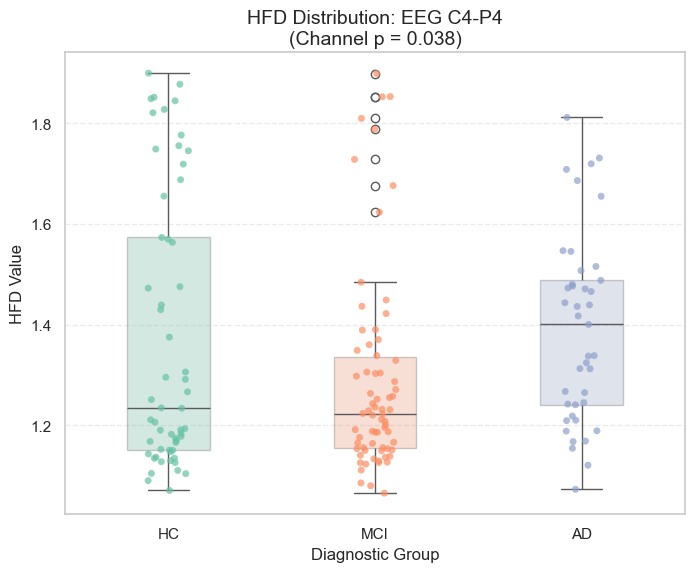

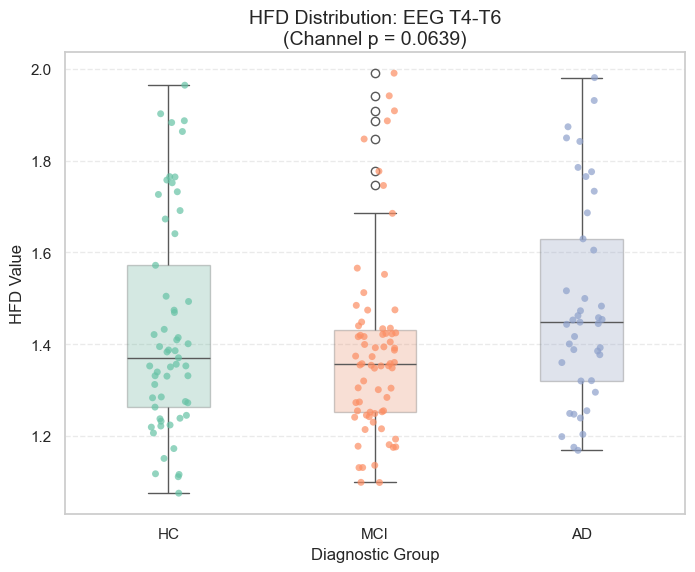

In [55]:
# 取得 anova_df 裡面所有的通道名稱與對應的 p-value
for index, row in anova_df.iterrows():
    ch = row['Channel']
    p_val = row['p-value']
    
    # 每個通道都獨立開一個 8x6 的新視窗/畫布
    plt.figure(figsize=(8, 6))

    # 1. 繪製盒狀圖
    sns.boxplot(x='Group', y=ch, data=all_hfd_df, 
                order=['HC', 'MCI', 'AD'], 
                hue='Group', palette='Set2', legend=False,
                width=0.4, boxprops=dict(alpha=0.3))

    # 2. 疊加點狀圖
    sns.stripplot(x='Group', y=ch, data=all_hfd_df, 
                  order=['HC', 'MCI', 'AD'], 
                  hue='Group', palette='Set2', legend=False,
                  size=5, jitter=True, alpha=0.7)

    # 3. 設定標題與標籤（完全複製你原本的格式）
    plt.title(f'HFD Distribution: {ch}\n(Channel p = {p_val})', fontsize=14)
    plt.ylabel('HFD Value', fontsize=12)
    plt.xlabel('Diagnostic Group', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # 4. 顯示圖片
    plt.show()

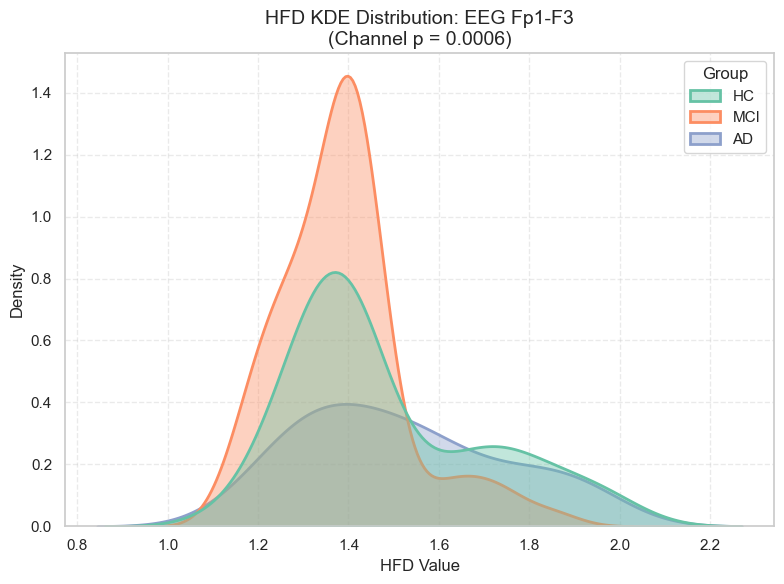

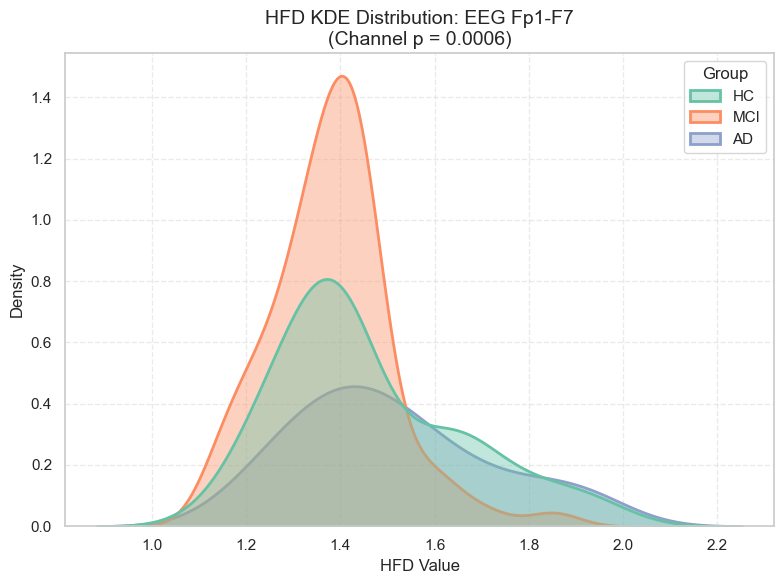

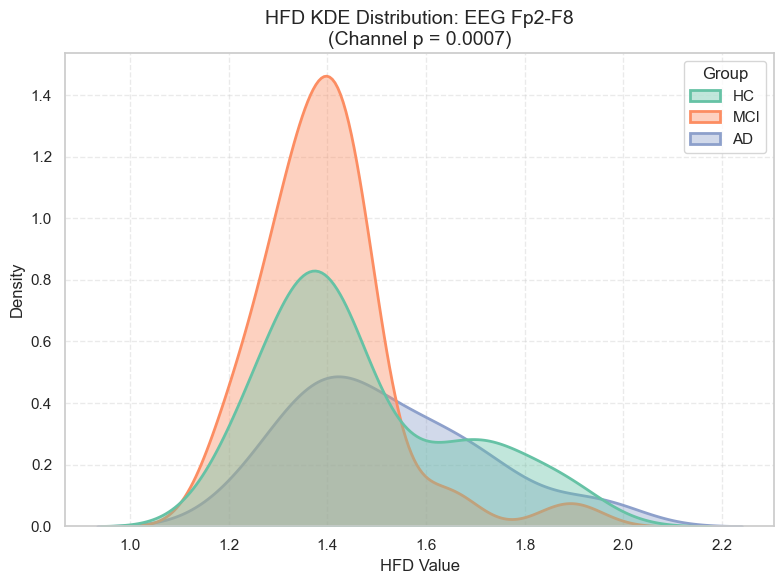

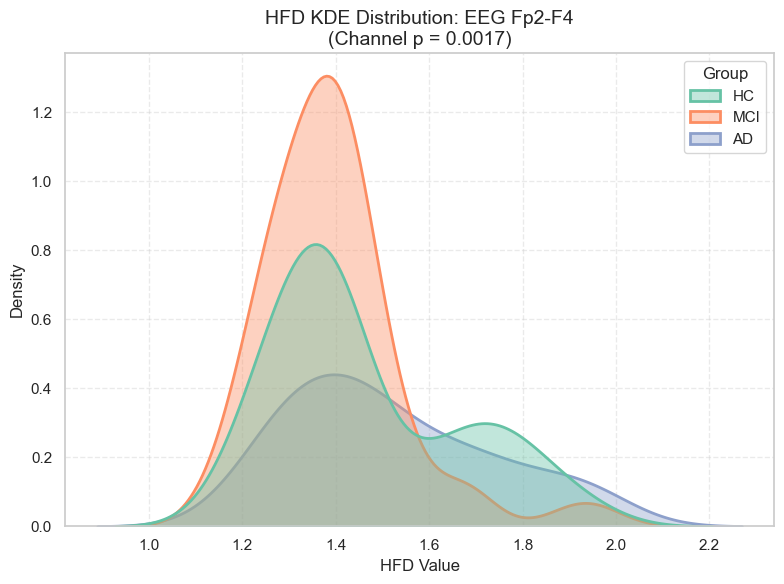

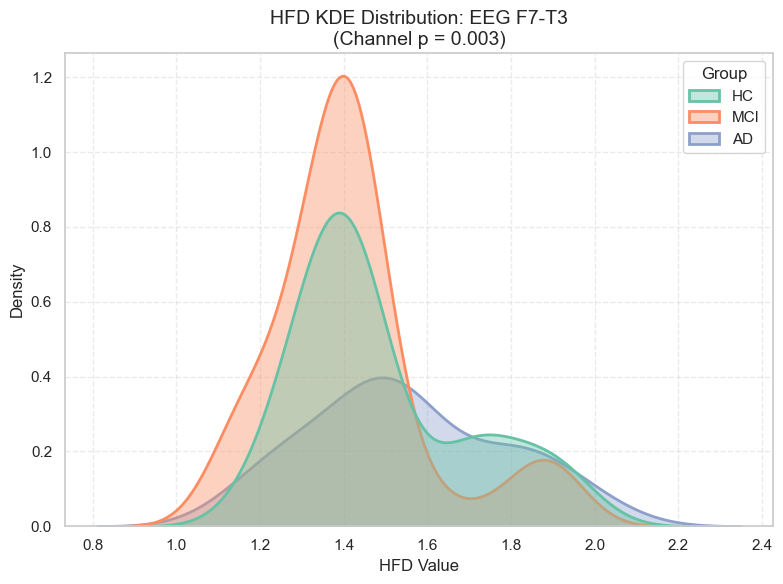

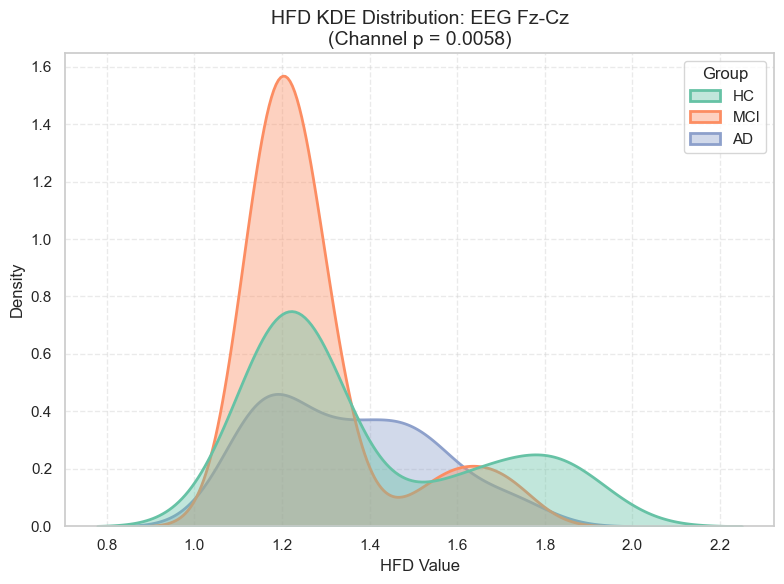

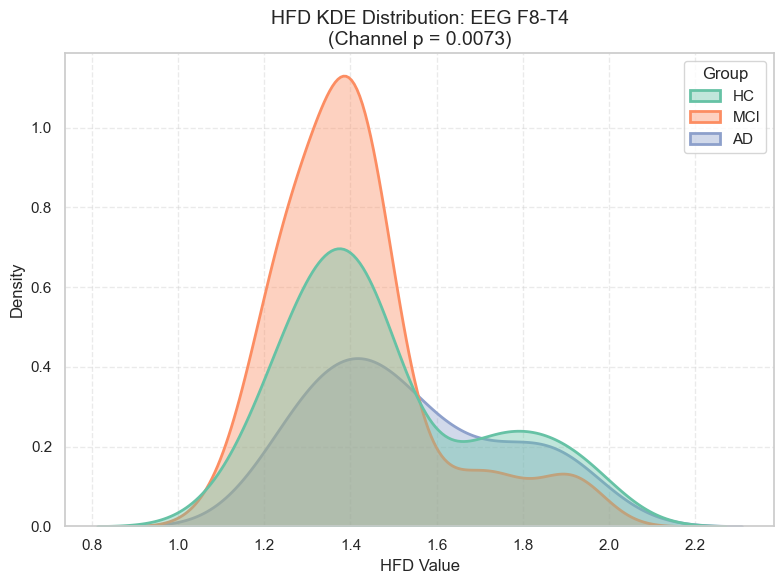

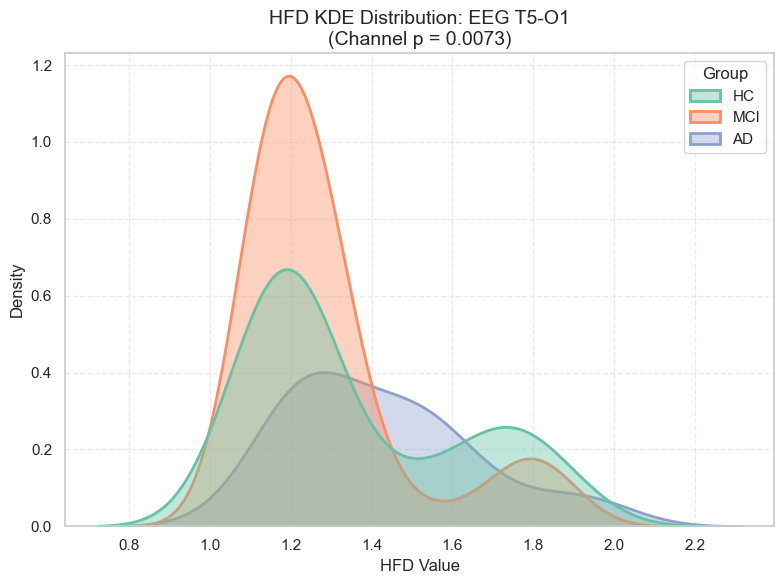

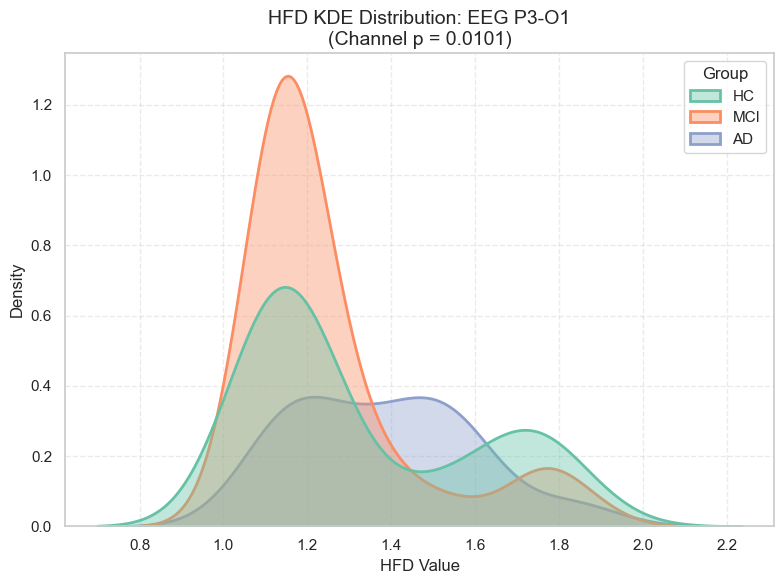

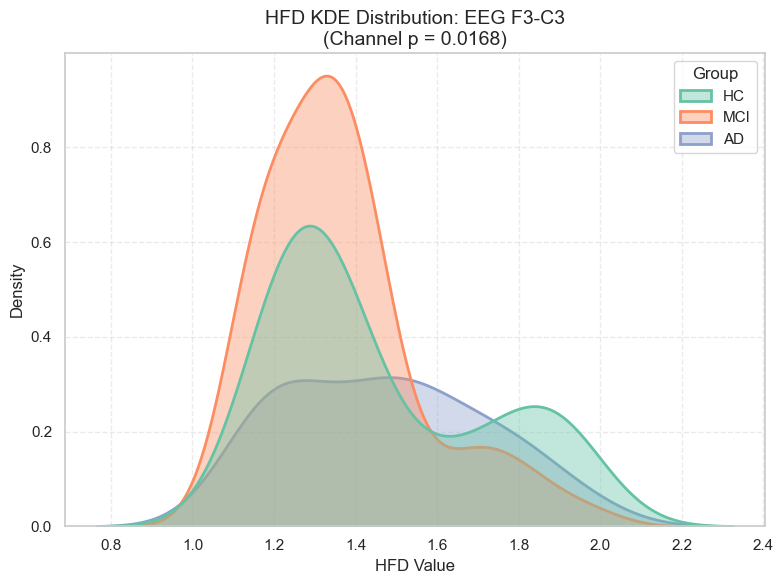

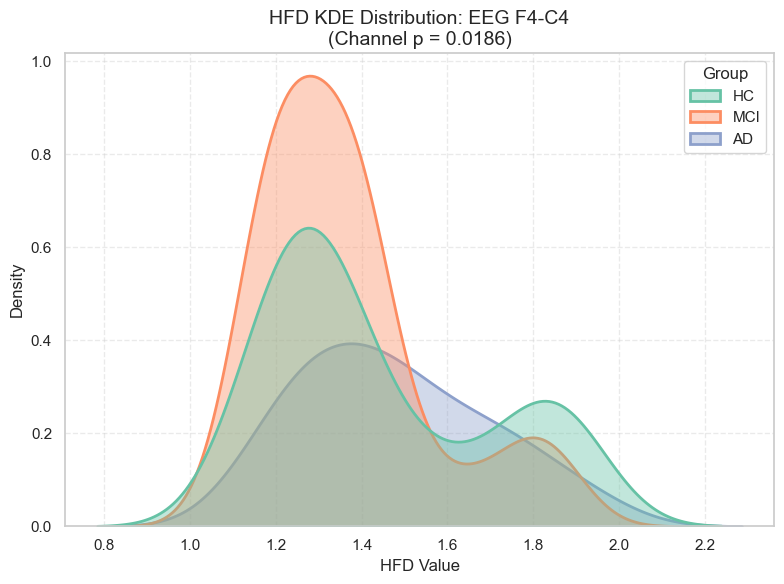

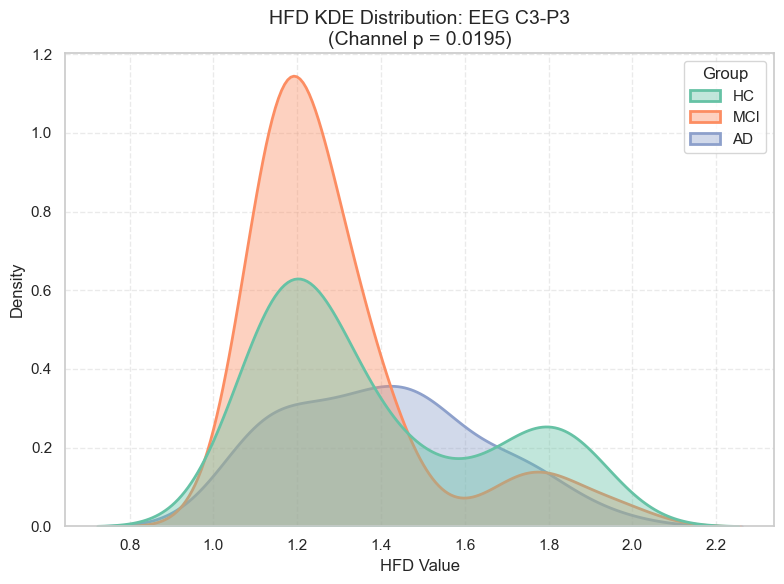

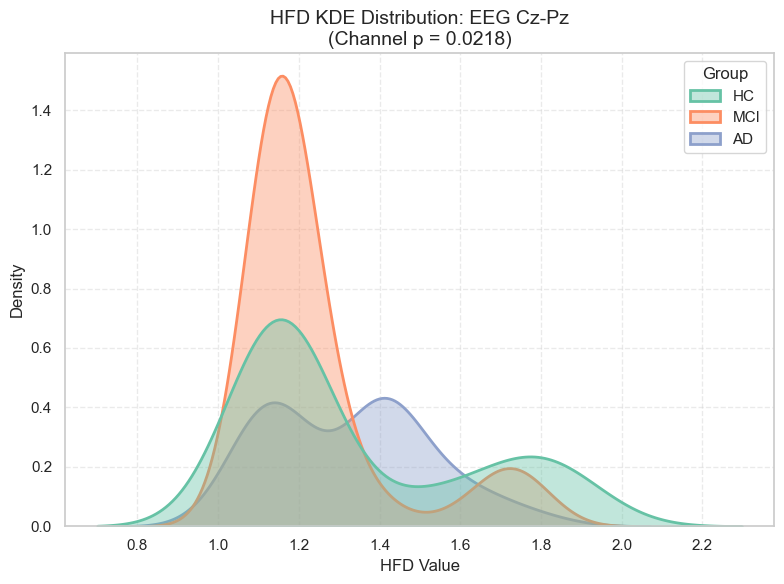

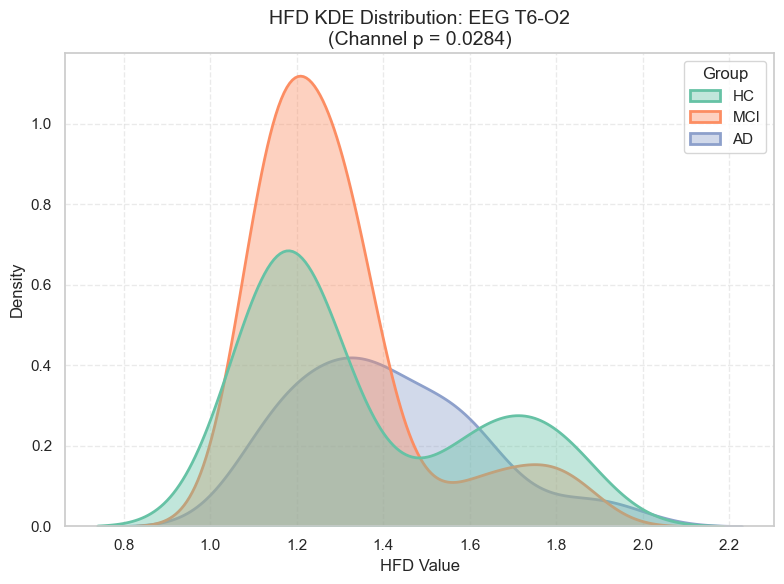

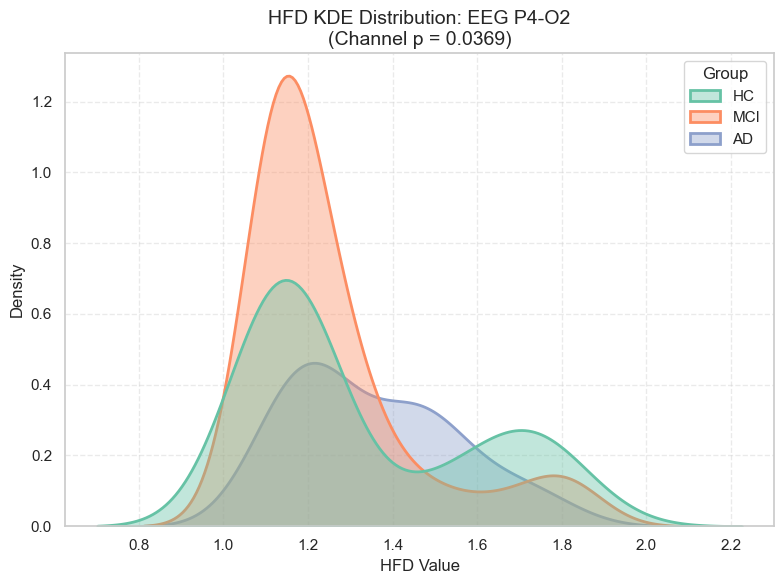

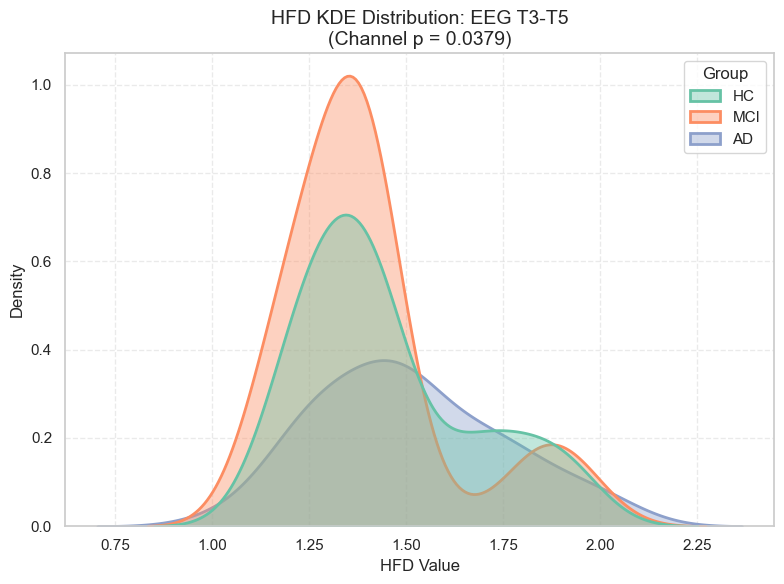

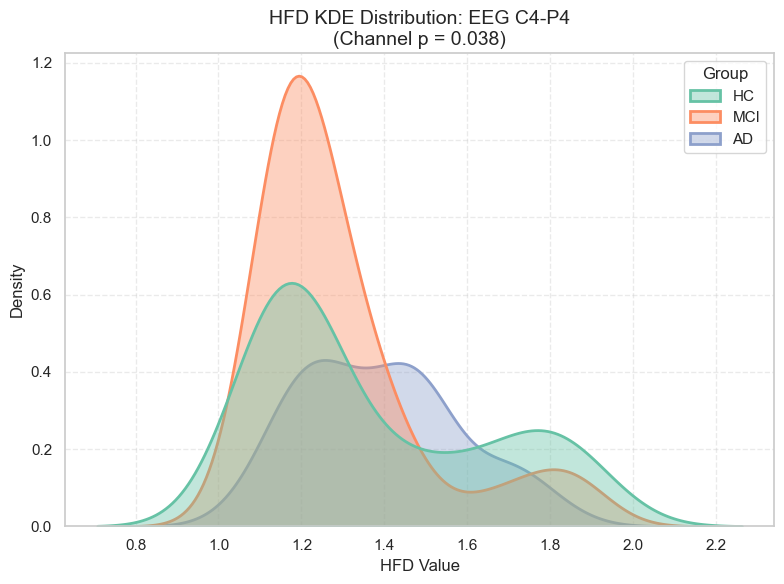

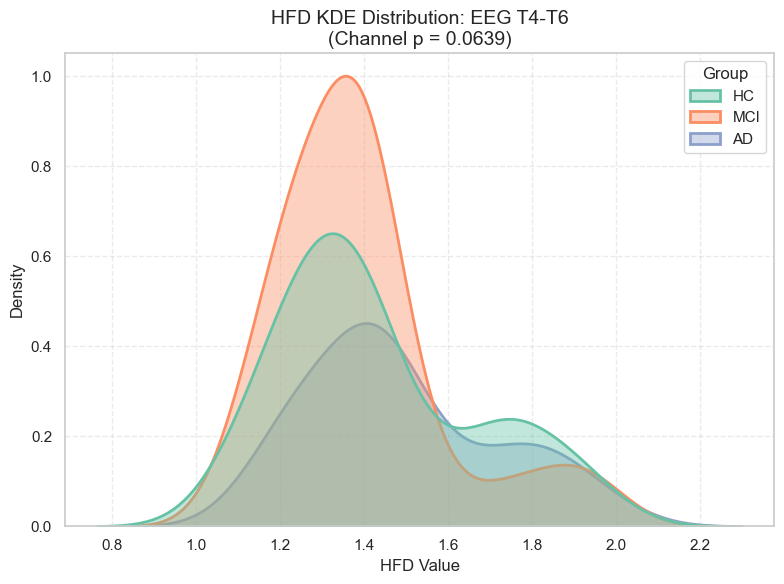

In [56]:
# 遍歷所有通道，依據 anova_df 的順序（p-value 由小到大）繪製 KDE 圖
for index, row in anova_df.iterrows():
    ch = row['Channel']
    p_val = row['p-value']
    
    # 每個通道獨立開一個 8x6 的新畫布
    plt.figure(figsize=(8, 6))

    # 繪製 KDE 曲線，fill=True 會填滿下方陰影，alpha 控制透明度
    sns.kdeplot(data=all_hfd_df, x=ch, hue='Group', 
                hue_order=['HC', 'MCI', 'AD'], palette='Set2',
                fill=True, alpha=0.4, linewidth=2)

    # 設定標題與標籤
    plt.title(f'HFD KDE Distribution: {ch}\n(Channel p = {p_val})', fontsize=14)
    plt.xlabel('HFD Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    # 加上網格方便對齊
    plt.grid(axis='both', linestyle='--', alpha=0.4)

    # 顯示圖片
    plt.tight_layout()
    plt.show()

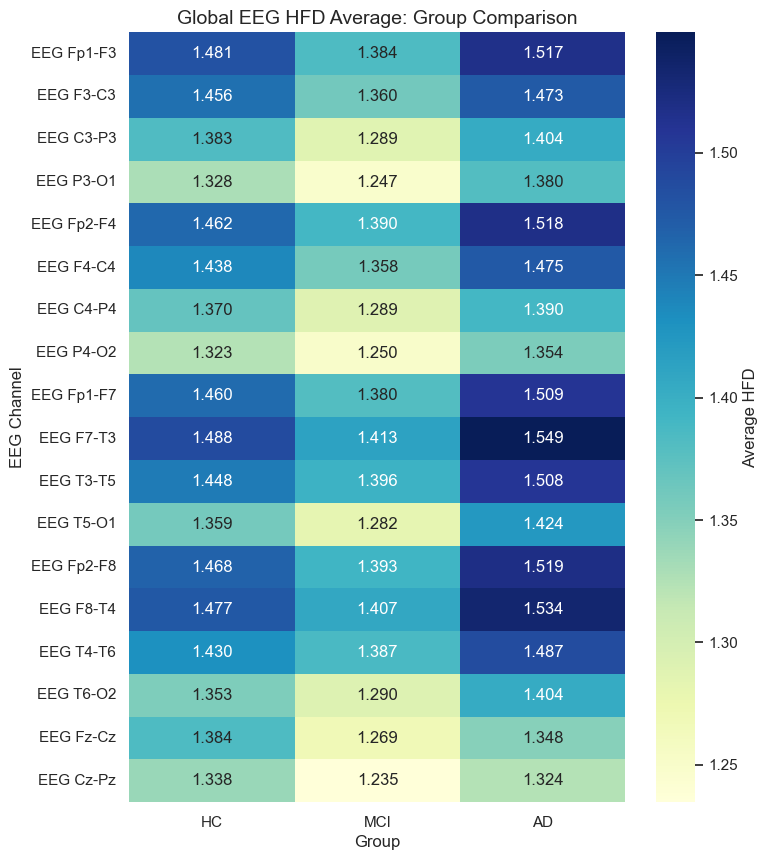

In [57]:
# 1. 直接從 all_hfd_df 計算各組平均值並轉置
heatmap_data = all_hfd_df.groupby('Group')[channels].mean().reindex(['HC', 'MCI', 'AD']).T

plt.figure(figsize=(8, 10))

# 2. 繪製熱圖
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.3f', 
            cbar_kws={'label': 'Average HFD'})
  
plt.title('Global EEG HFD Average: Group Comparison', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('EEG Channel', fontsize=12)
plt.show()